### Imports

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

%matplotlib inline 
mpl.rcParams['figure.dpi'] = 300

In [3]:
from sklearn.preprocessing import Normalizer

In [4]:
from chart_studio import plotly
import plotly.figure_factory as ff

In [5]:
pd.options.display.max_rows = 4000
pd.options.display.max_columns = 4000

In [6]:
DATA_VERSION = 'v5'

In [7]:
gov_arch_csv = '../data/' + DATA_VERSION + '/communities_data_prepped.csv'

In [8]:
gov_df = pd.read_csv(gov_arch_csv)

In [9]:
gov_df.head()

,Name,Institutions,Mechanism,Notes,Time span,Geography,Size,Source,Metanotes,Heterogeneity,FC comments,expert check,Time span: Start,Time span: End,SCCS,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figure

# Courts Analysis 

In [10]:
col_list = list(gov_df.columns.values)
col_list

['Name',
 'Institutions',
 'Mechanism',
 'Notes',
 'Time span',
 'Geography',
 'Size',
 'Source',
 'Metanotes',
 'Heterogeneity ',
 'FC comments',
 'expert check',
 'Time span: Start',
 'Time span: End',
 'SCCS',
 'is_SCCS',
 'decision_making_mechanisms_include_representation',
 'enforcement_mechanisms_include_paying_damages_compensation',
 'decision_making_mechanisms_include_temporary_position_of_power_term_limits',
 'enforcement_mechanisms_include_forced_labour',
 'decision_making_mechanisms_include_remunerated_position',
 'access_mechanisms_include_property_requirement',
 'access_mechanisms_include_induction_rite_ceremony',
 'access_mechanisms_include_gerontocracy',
 'decision_making_mechanisms_include_majority_voting',
 'enforcement_mechanisms_include_graduated_sanctions',
 'decision_making_mechanisms_include_plurality_voting',
 'enforcement_mechanisms_include_monitoring',
 'decision_making_mechanisms_include_assembly_local',
 'decision_making_mechanisms_include_petition',
 'access

In [11]:
court_col = ['enforcement_mechanisms_include_tribunal_court_']

In [12]:
courts = 'enforcement_mechanisms_include_tribunal_court_'

In [13]:
courts_df = gov_df[(gov_df['enforcement_mechanisms_include_tribunal_court_'] == 1)]

In [14]:
no_courts_df = gov_df[(gov_df['enforcement_mechanisms_include_tribunal_court_'] == 0)]

In [15]:
courts_df.head()

,Name,Institutions,Mechanism,Notes,Time span,Geography,Size,Source,Metanotes,Heterogeneity,FC comments,expert check,Time span: Start,Time span: End,SCCS,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figure

In [16]:
no_courts_df.head()

,Name,Institutions,Mechanism,Notes,Time span,Geography,Size,Source,Metanotes,Heterogeneity,FC comments,expert check,Time span: Start,Time span: End,SCCS,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figure

In [17]:
courts_df.describe()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [18]:
no_courts_df.describe()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [19]:
gov_df[court_col].value_counts()

enforcement_mechanisms_include_tribunal_court_
0                                                 68
1                                                 23
Name: count, dtype: int64

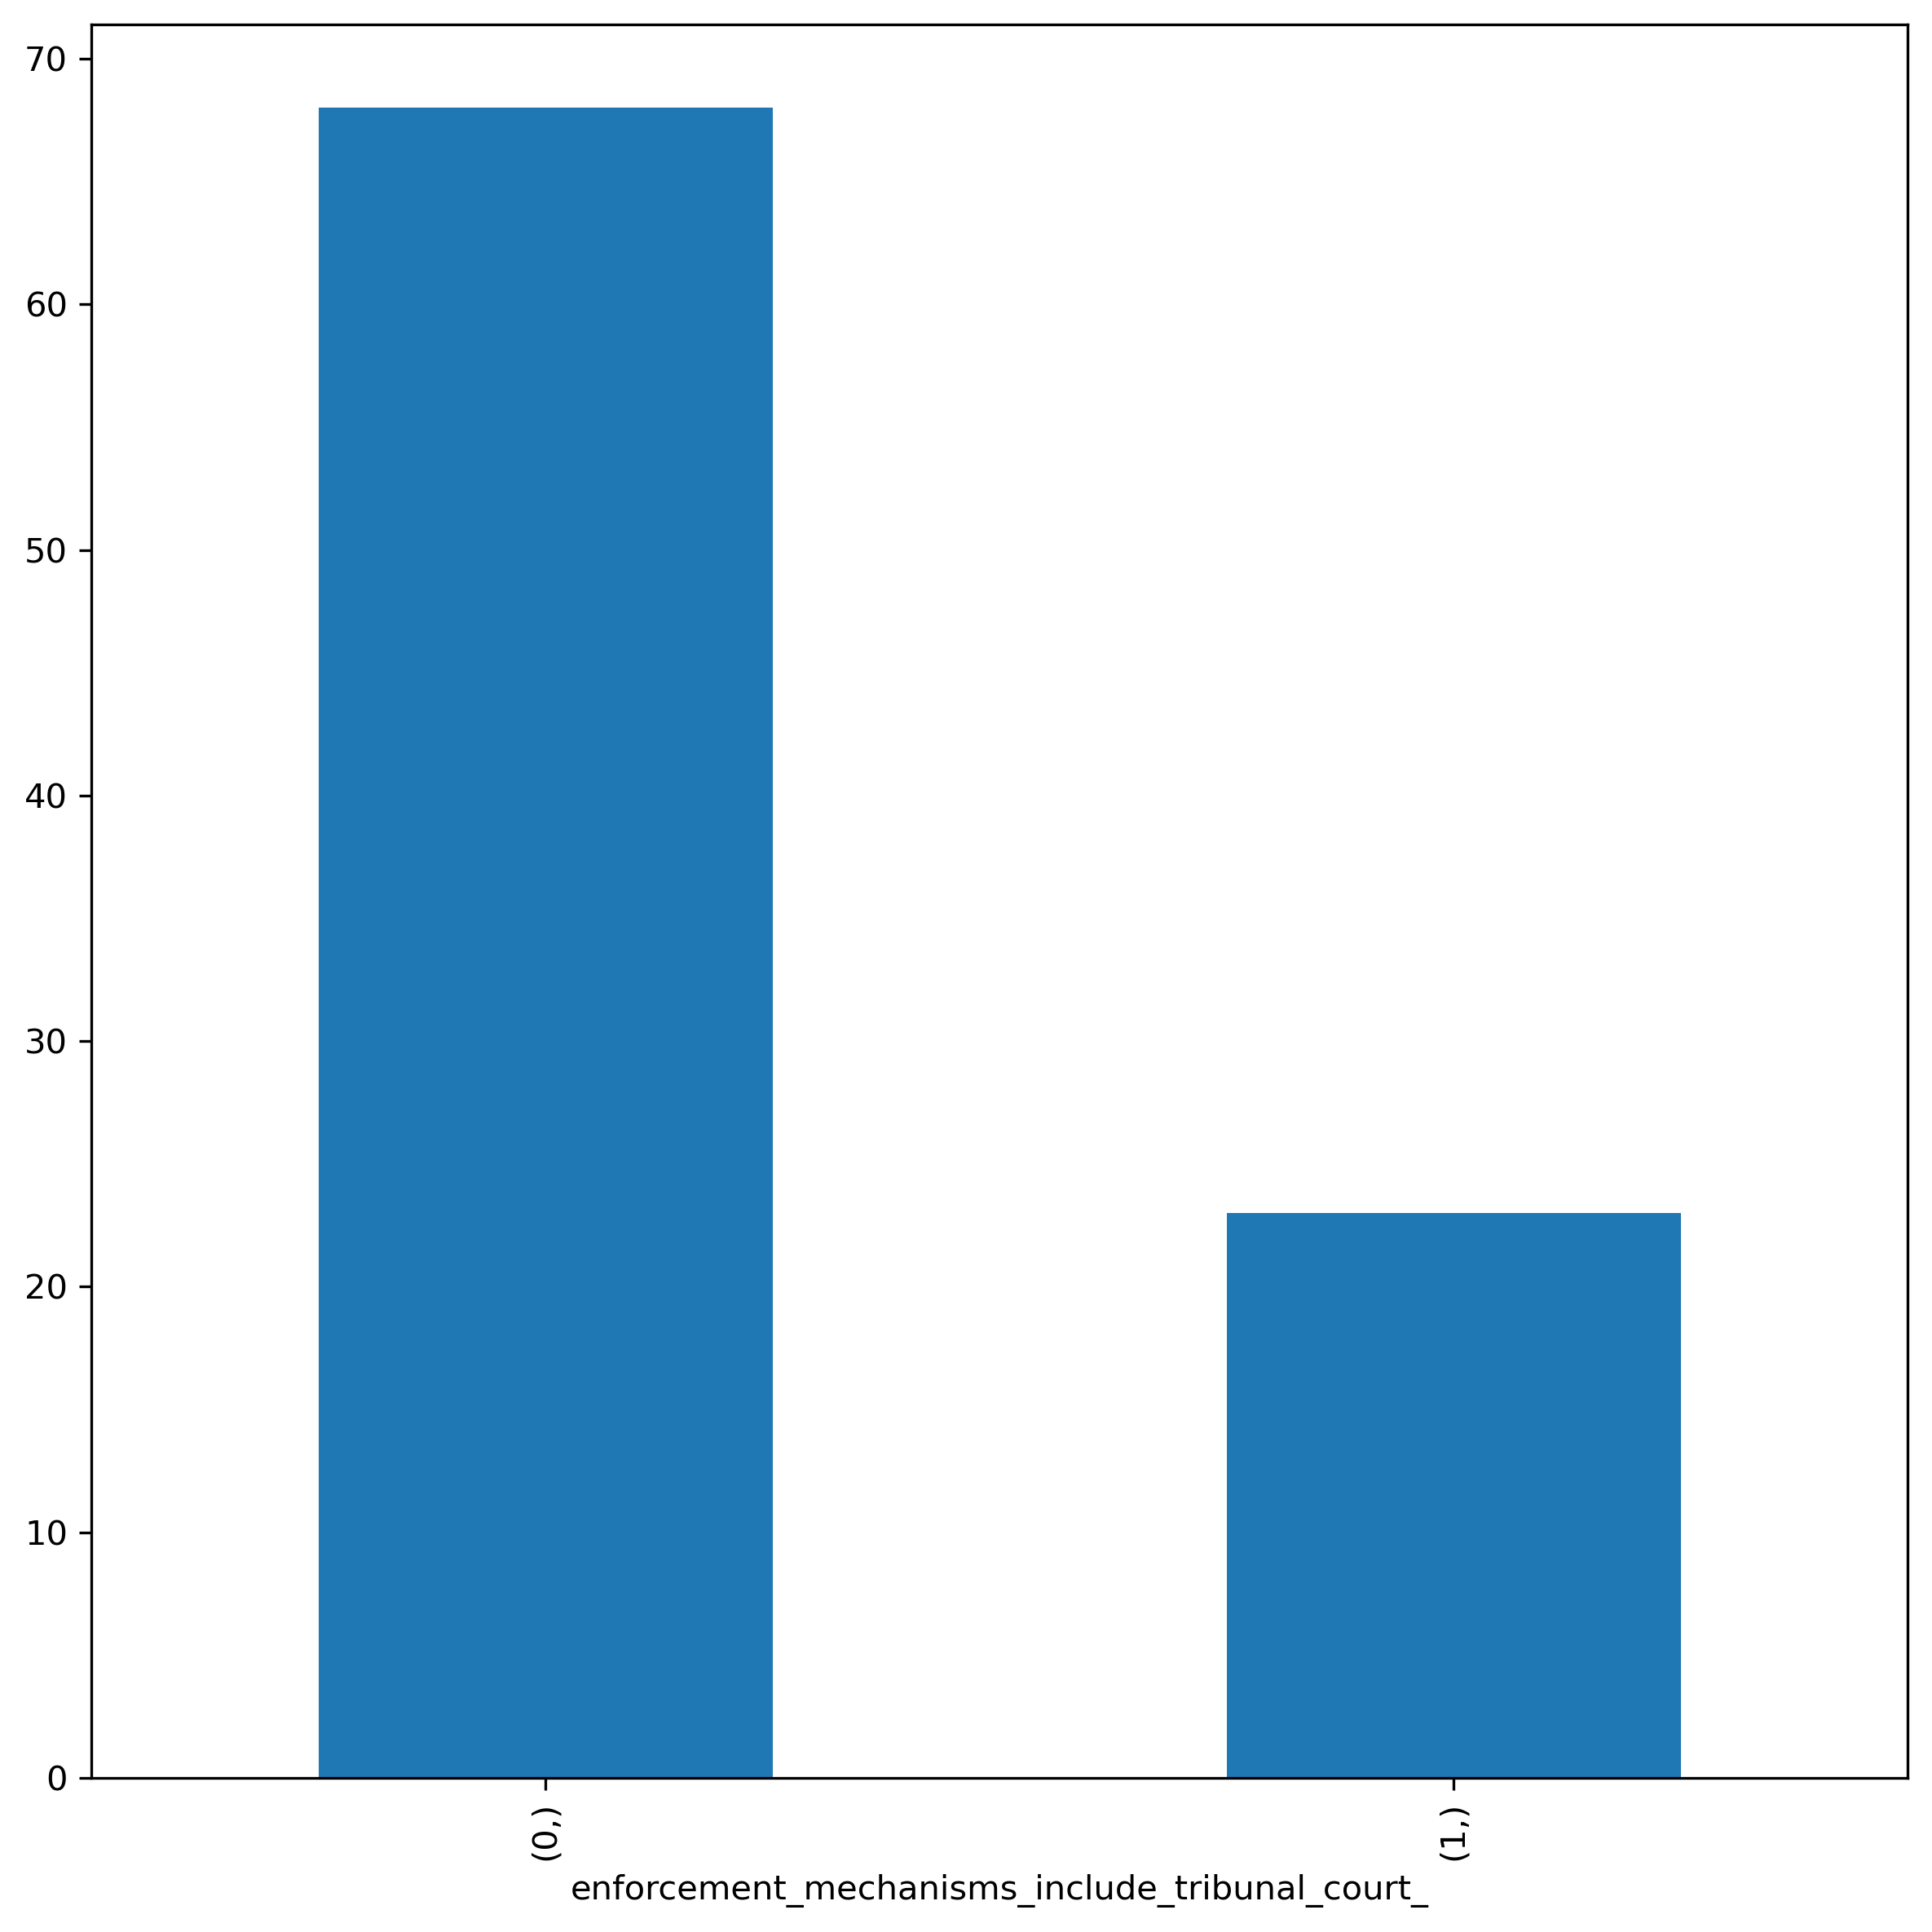

In [20]:
plt.figure(figsize=(8,8))

gov_df[court_col].value_counts().plot(kind='bar')

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/histogram.png')
plt.show()

## Correlations

In [21]:
data_plot = gov_df.select_dtypes(include=[np.number]).dropna()

In [22]:
data_plot.describe()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [23]:
normalized = Normalizer().fit_transform(data_plot)

norm_df = pd.DataFrame(normalized)
norm_df.columns = data_plot.columns
norm_corr = norm_df.corr()

norm_corr.head()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [24]:
courts_corr = norm_corr[court_col]

In [25]:
courts_corr

,enforcement_mechanisms_include_tribunal_court_
Time span: Start,-0.248448
Time span: End,-0.205410
is_SCCS,-0.087714
decision_making_mechanisms_include_representation,-0.041349
enforcement_mechanisms_include_paying_damages_compensation,0.421351
decision_making_mechanisms_include_temporary_position_of_power_term_limits,0.433114
enforcement_mechanisms_include_forced_labour,-0.036783
decision_making_mechanisms_include_remunerated_position,0.296929
access_mechanisms_include_property_requirement,0.361992
access_mechanisms_include_induction_rite_ceremony,0.029160


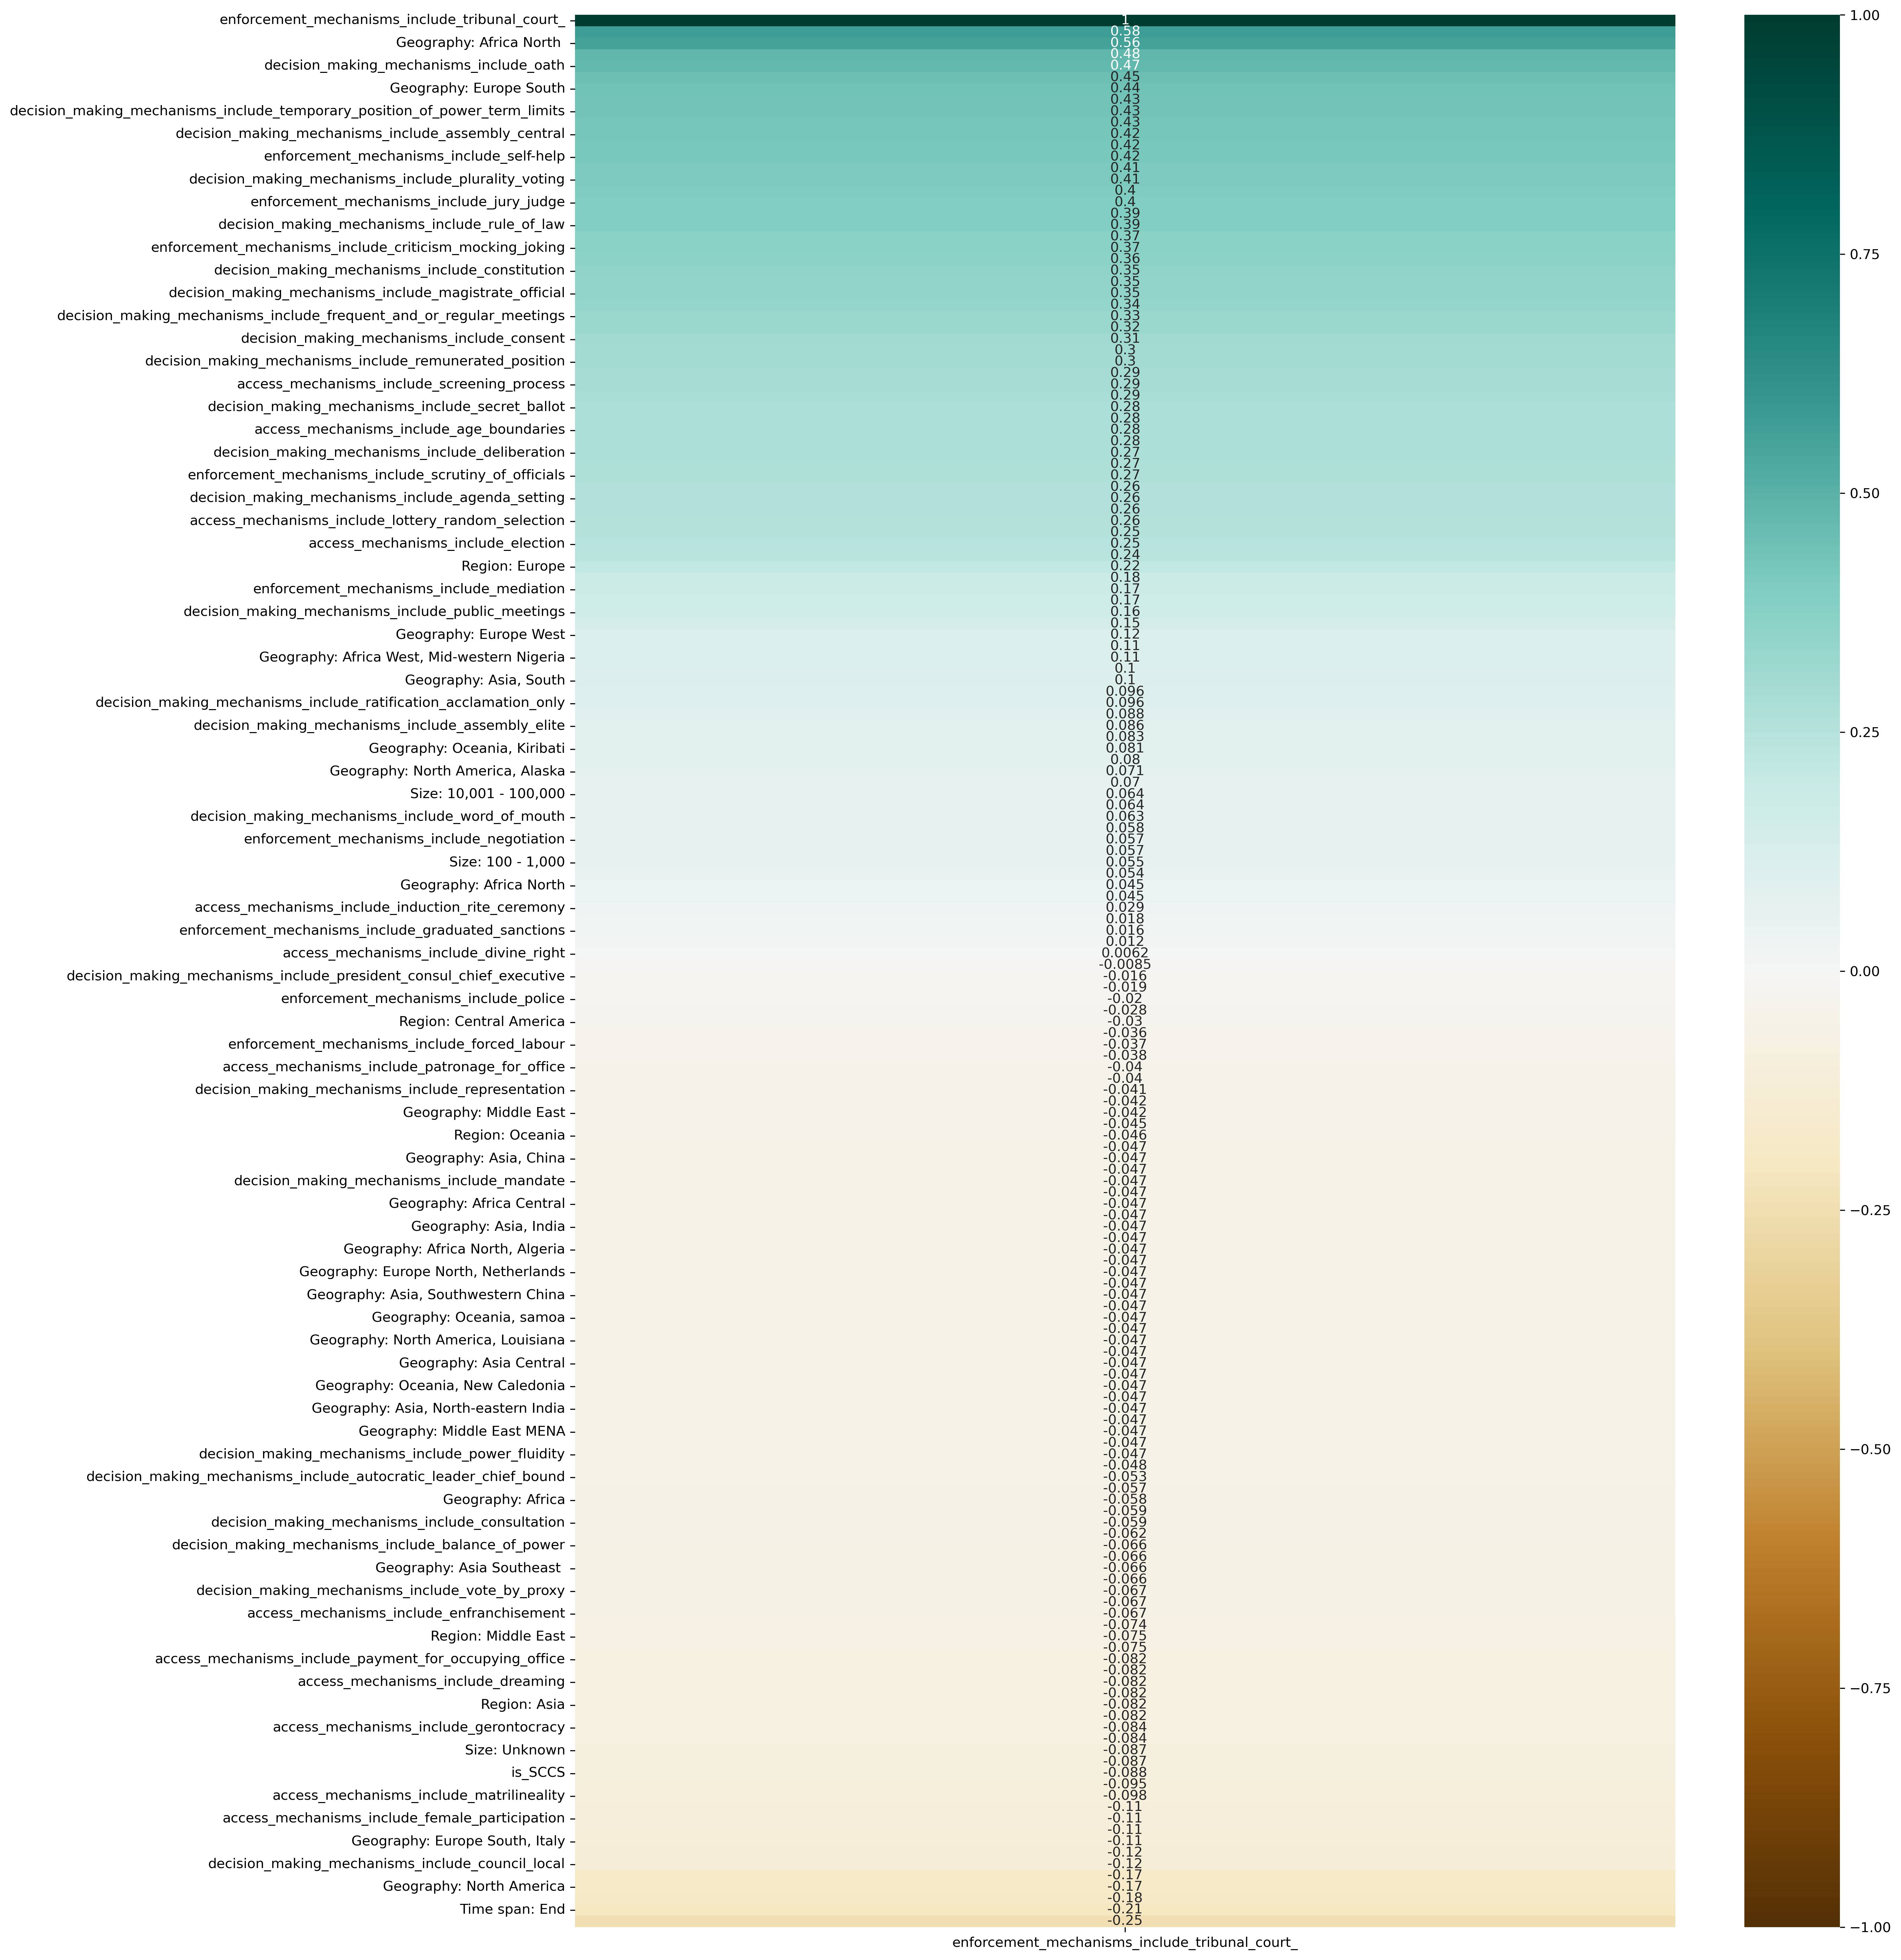

In [26]:
plt.figure(figsize=(20,20))
sns.heatmap(
    courts_corr.sort_values(by='enforcement_mechanisms_include_tribunal_court_', ascending=False), 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/courts_corr.png')
plt.show()

## Courts Analysis: Mechanisms

### Access

In [27]:
access_courts_corr = courts_corr[courts_corr.index.str.startswith('access')]

In [28]:
access_courts_corr

,enforcement_mechanisms_include_tribunal_court_
access_mechanisms_include_property_requirement,0.361992
access_mechanisms_include_induction_rite_ceremony,0.029160
access_mechanisms_include_gerontocracy,-0.083923
access_mechanisms_include_enfranchisement,-0.066801
access_mechanisms_include_age_boundaries,0.276648
access_mechanisms_include_screening_process,0.289182
access_mechanisms_include_meritocracy,-0.172675
access_mechanisms_include_matriarchy,-0.019081
access_mechanisms_include_heredity,-0.182878
access_mechanisms_include_co-optation,-0.081890


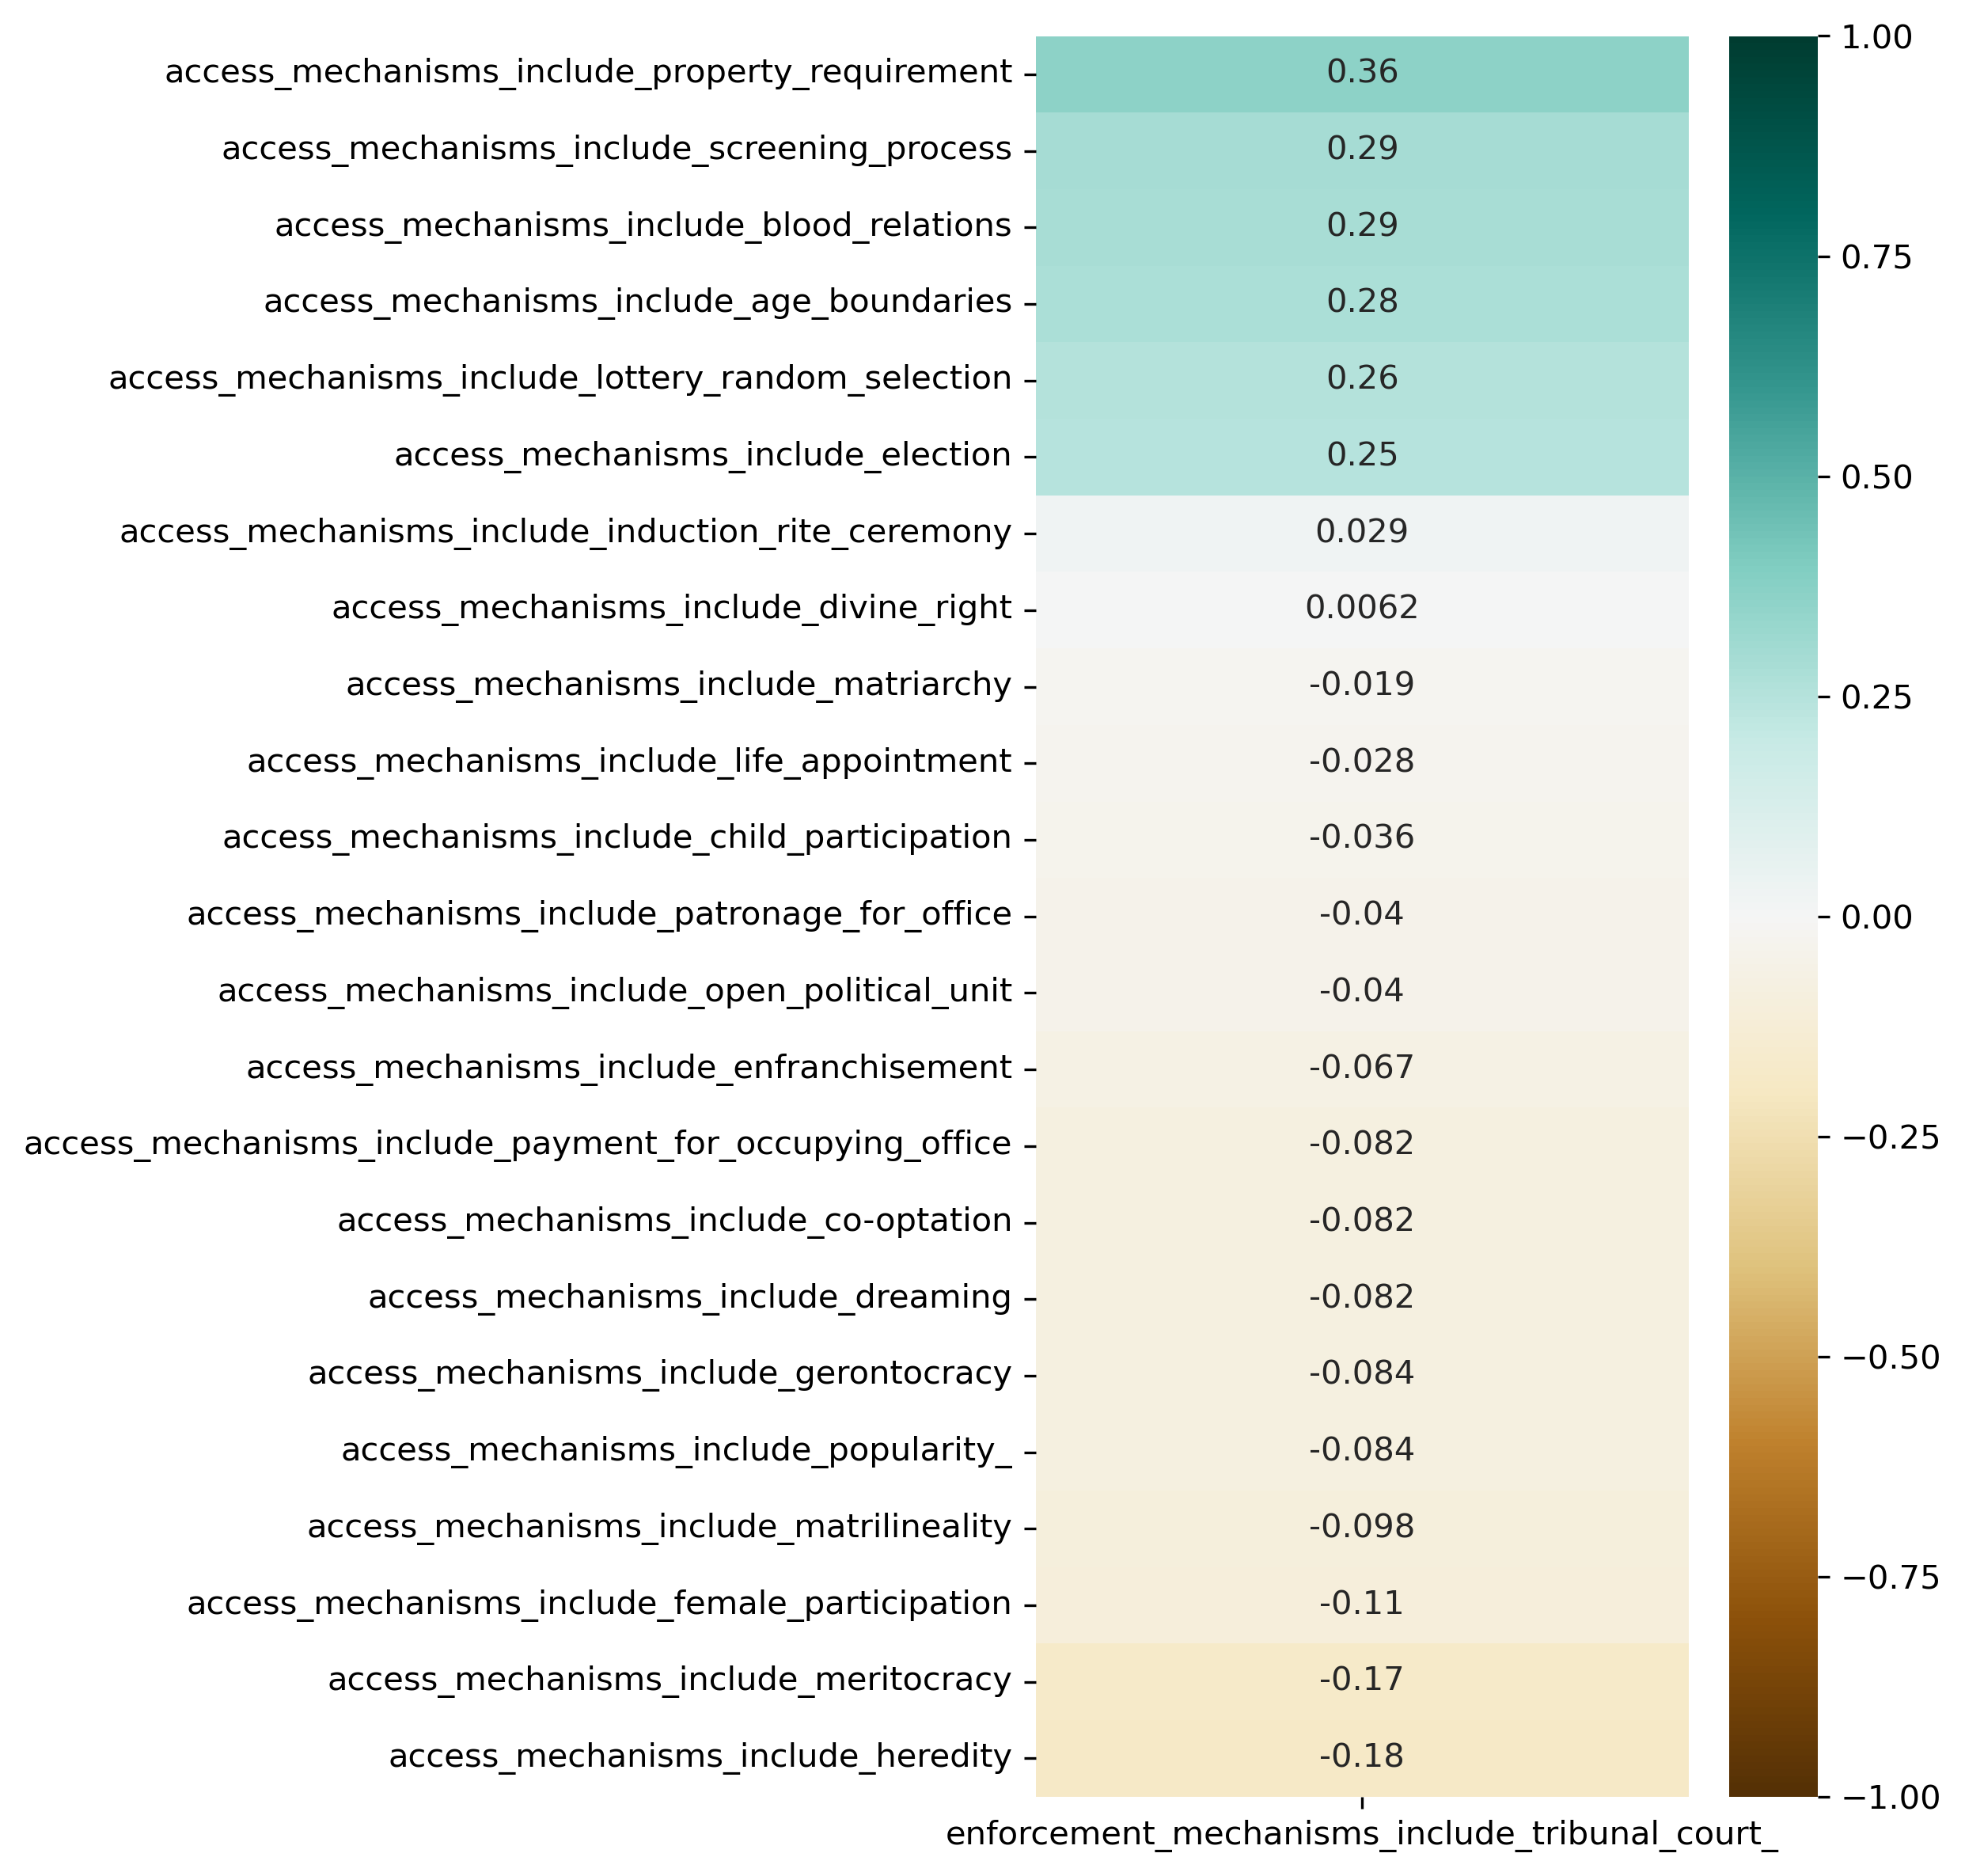

In [29]:
plt.figure(figsize=(8,8))
sns.heatmap(
    access_courts_corr.sort_values(by=courts, ascending=False), 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/access_courts_corr.png')
plt.show()

### Decision Making

In [30]:
dm_courts_corr = courts_corr[courts_corr.index.str.startswith('decision_making')]

In [31]:
dm_courts_corr

,enforcement_mechanisms_include_tribunal_court_
decision_making_mechanisms_include_representation,-0.041349
decision_making_mechanisms_include_temporary_position_of_power_term_limits,0.433114
decision_making_mechanisms_include_remunerated_position,0.296929
decision_making_mechanisms_include_majority_voting,0.323654
decision_making_mechanisms_include_plurality_voting,0.413185
decision_making_mechanisms_include_assembly_local,0.017522
decision_making_mechanisms_include_petition,0.045098
decision_making_mechanisms_include_secret_ballot,0.278293
decision_making_mechanisms_include_coalition,-0.046984
decision_making_mechanisms_include_checks_and_balances,-0.008541


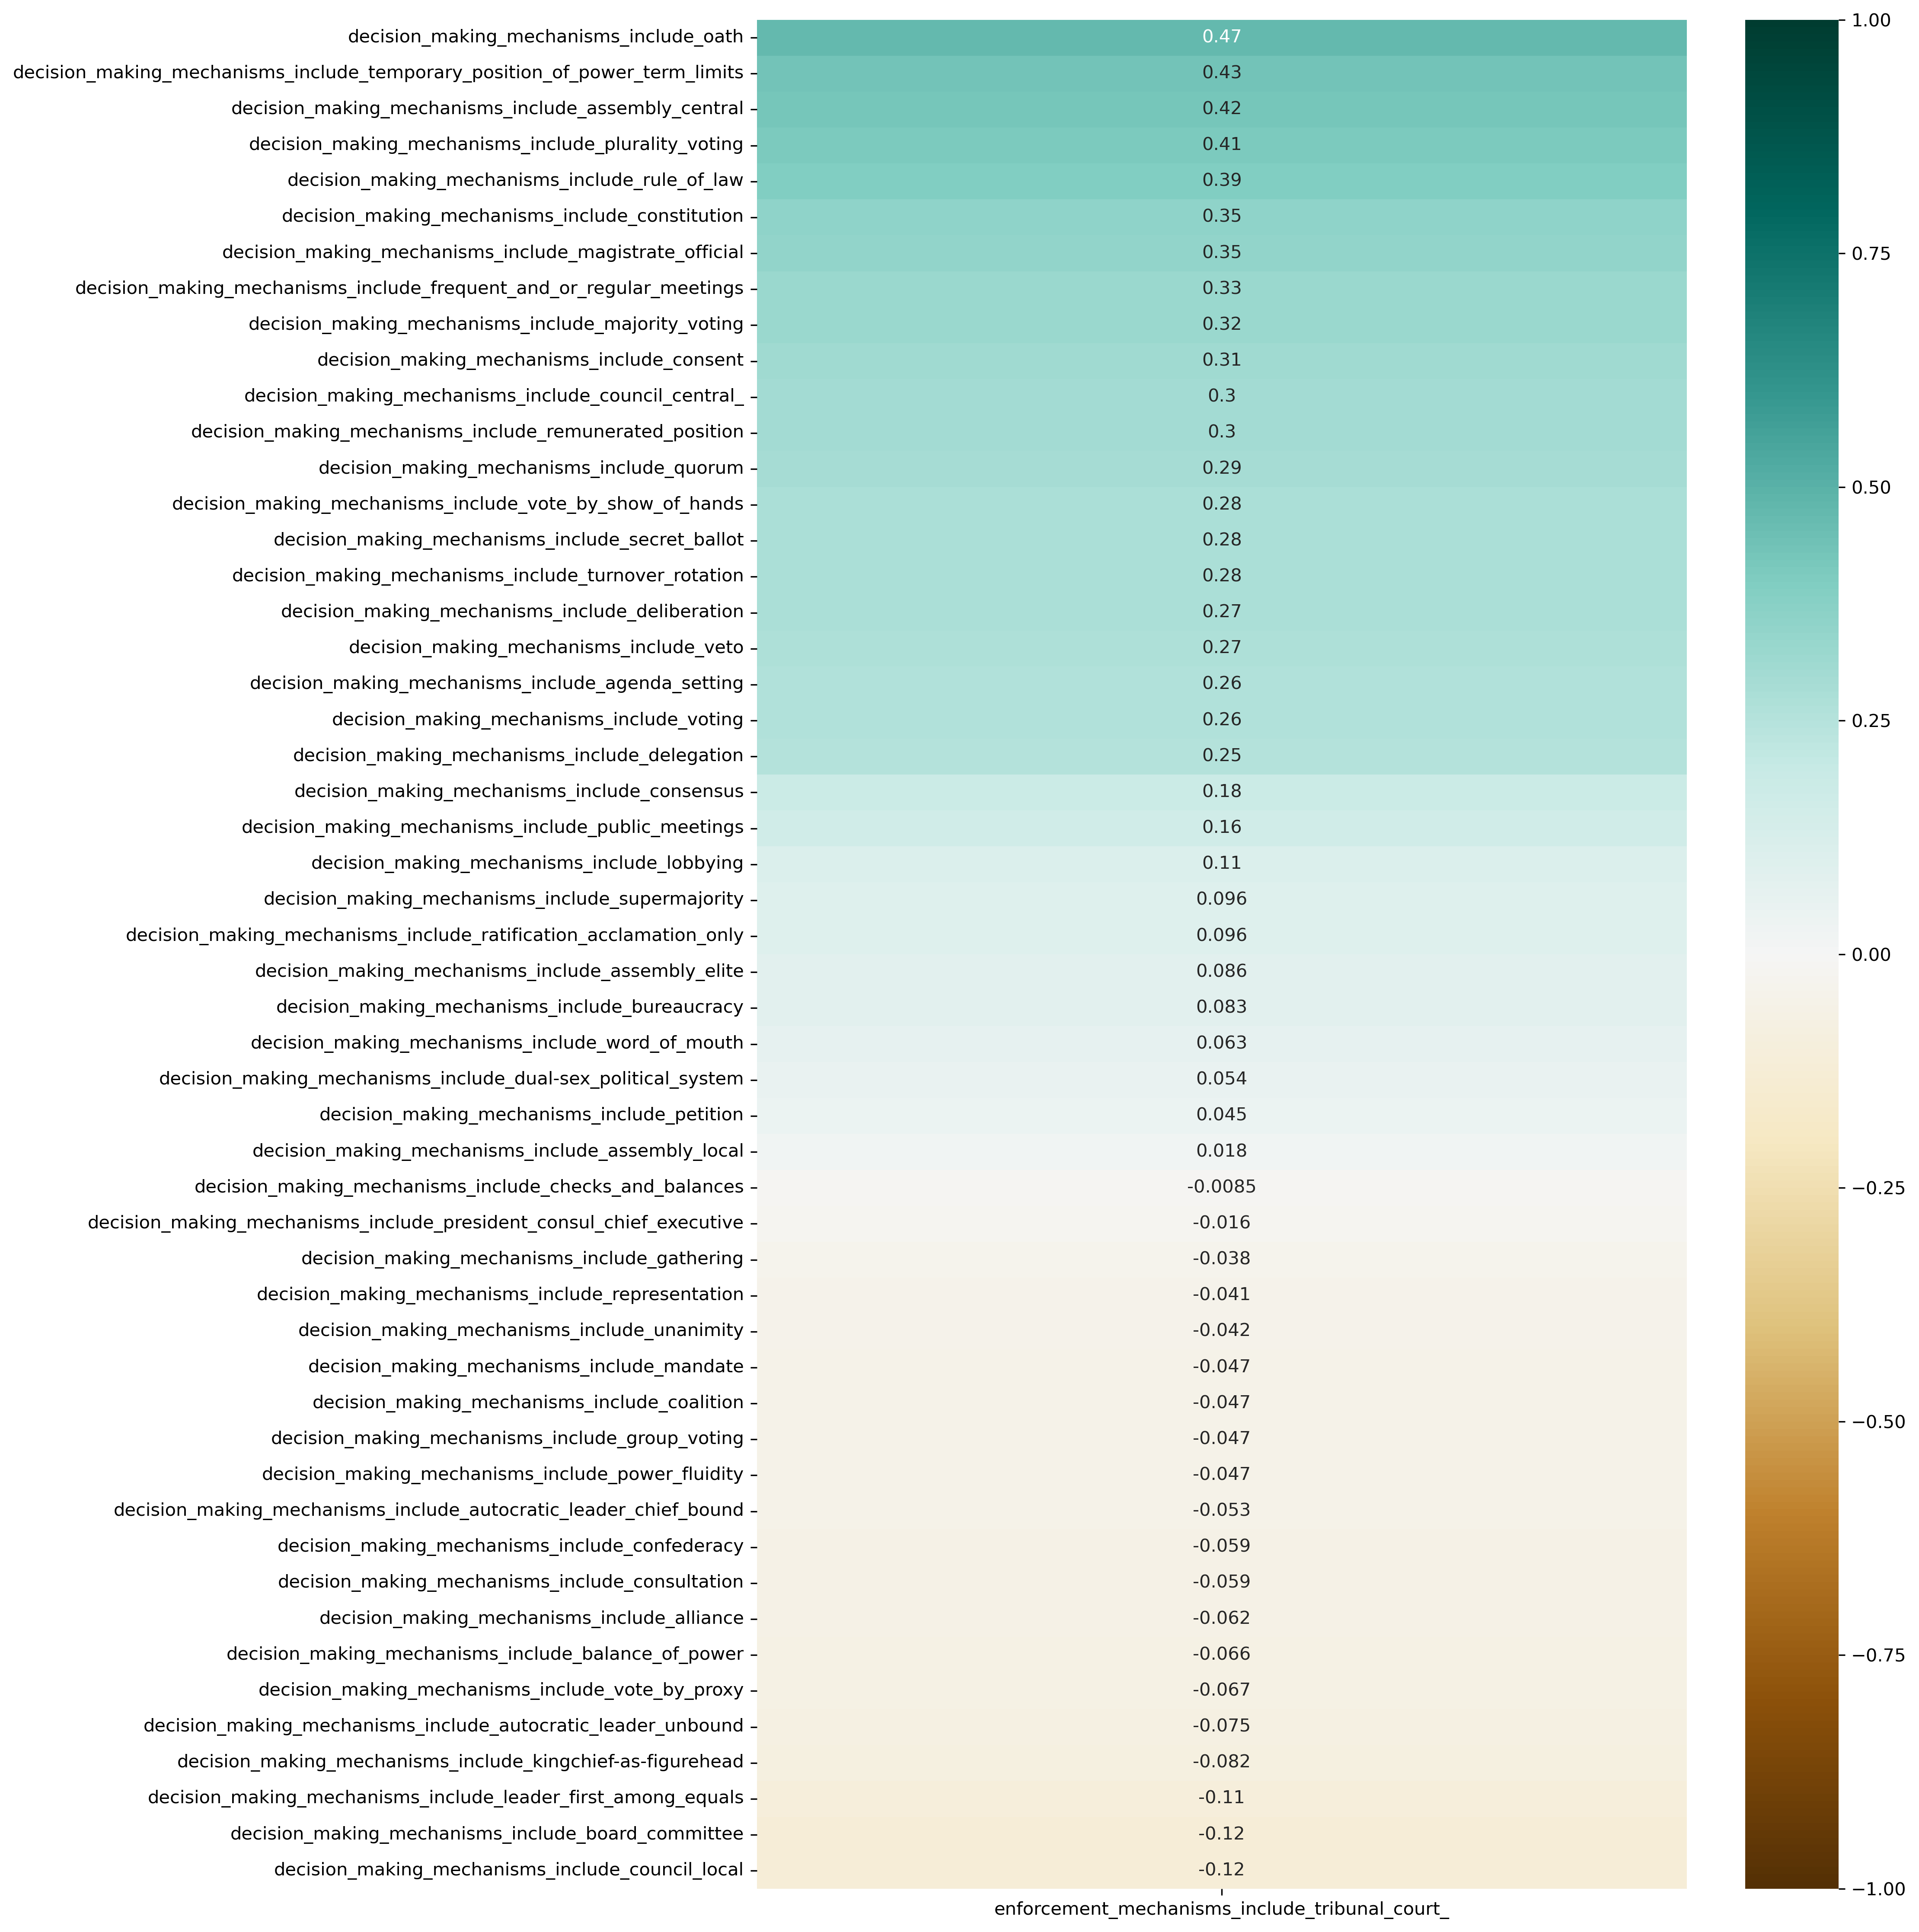

In [32]:
plt.figure(figsize=(15,15))
sns.heatmap(
    dm_courts_corr.sort_values(by=courts, ascending=False), 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/dm_courts_corr.png')
plt.show()

### Enforcement

In [33]:
enforcement_courts_corr = courts_corr[courts_corr.index.str.startswith('enforcement')]

In [34]:
enforcement_courts_corr

,enforcement_mechanisms_include_tribunal_court_
enforcement_mechanisms_include_paying_damages_compensation,0.421351
enforcement_mechanisms_include_forced_labour,-0.036783
enforcement_mechanisms_include_graduated_sanctions,0.015771
enforcement_mechanisms_include_monitoring,0.402026
enforcement_mechanisms_include_exit,-0.044762
enforcement_mechanisms_include_self-help,0.418063
enforcement_mechanisms_include_civil_disobedience,-0.046984
enforcement_mechanisms_include_criticism_mocking_joking,0.369685
enforcement_mechanisms_include_appeal,0.170112
enforcement_mechanisms_include_litigation,0.477040


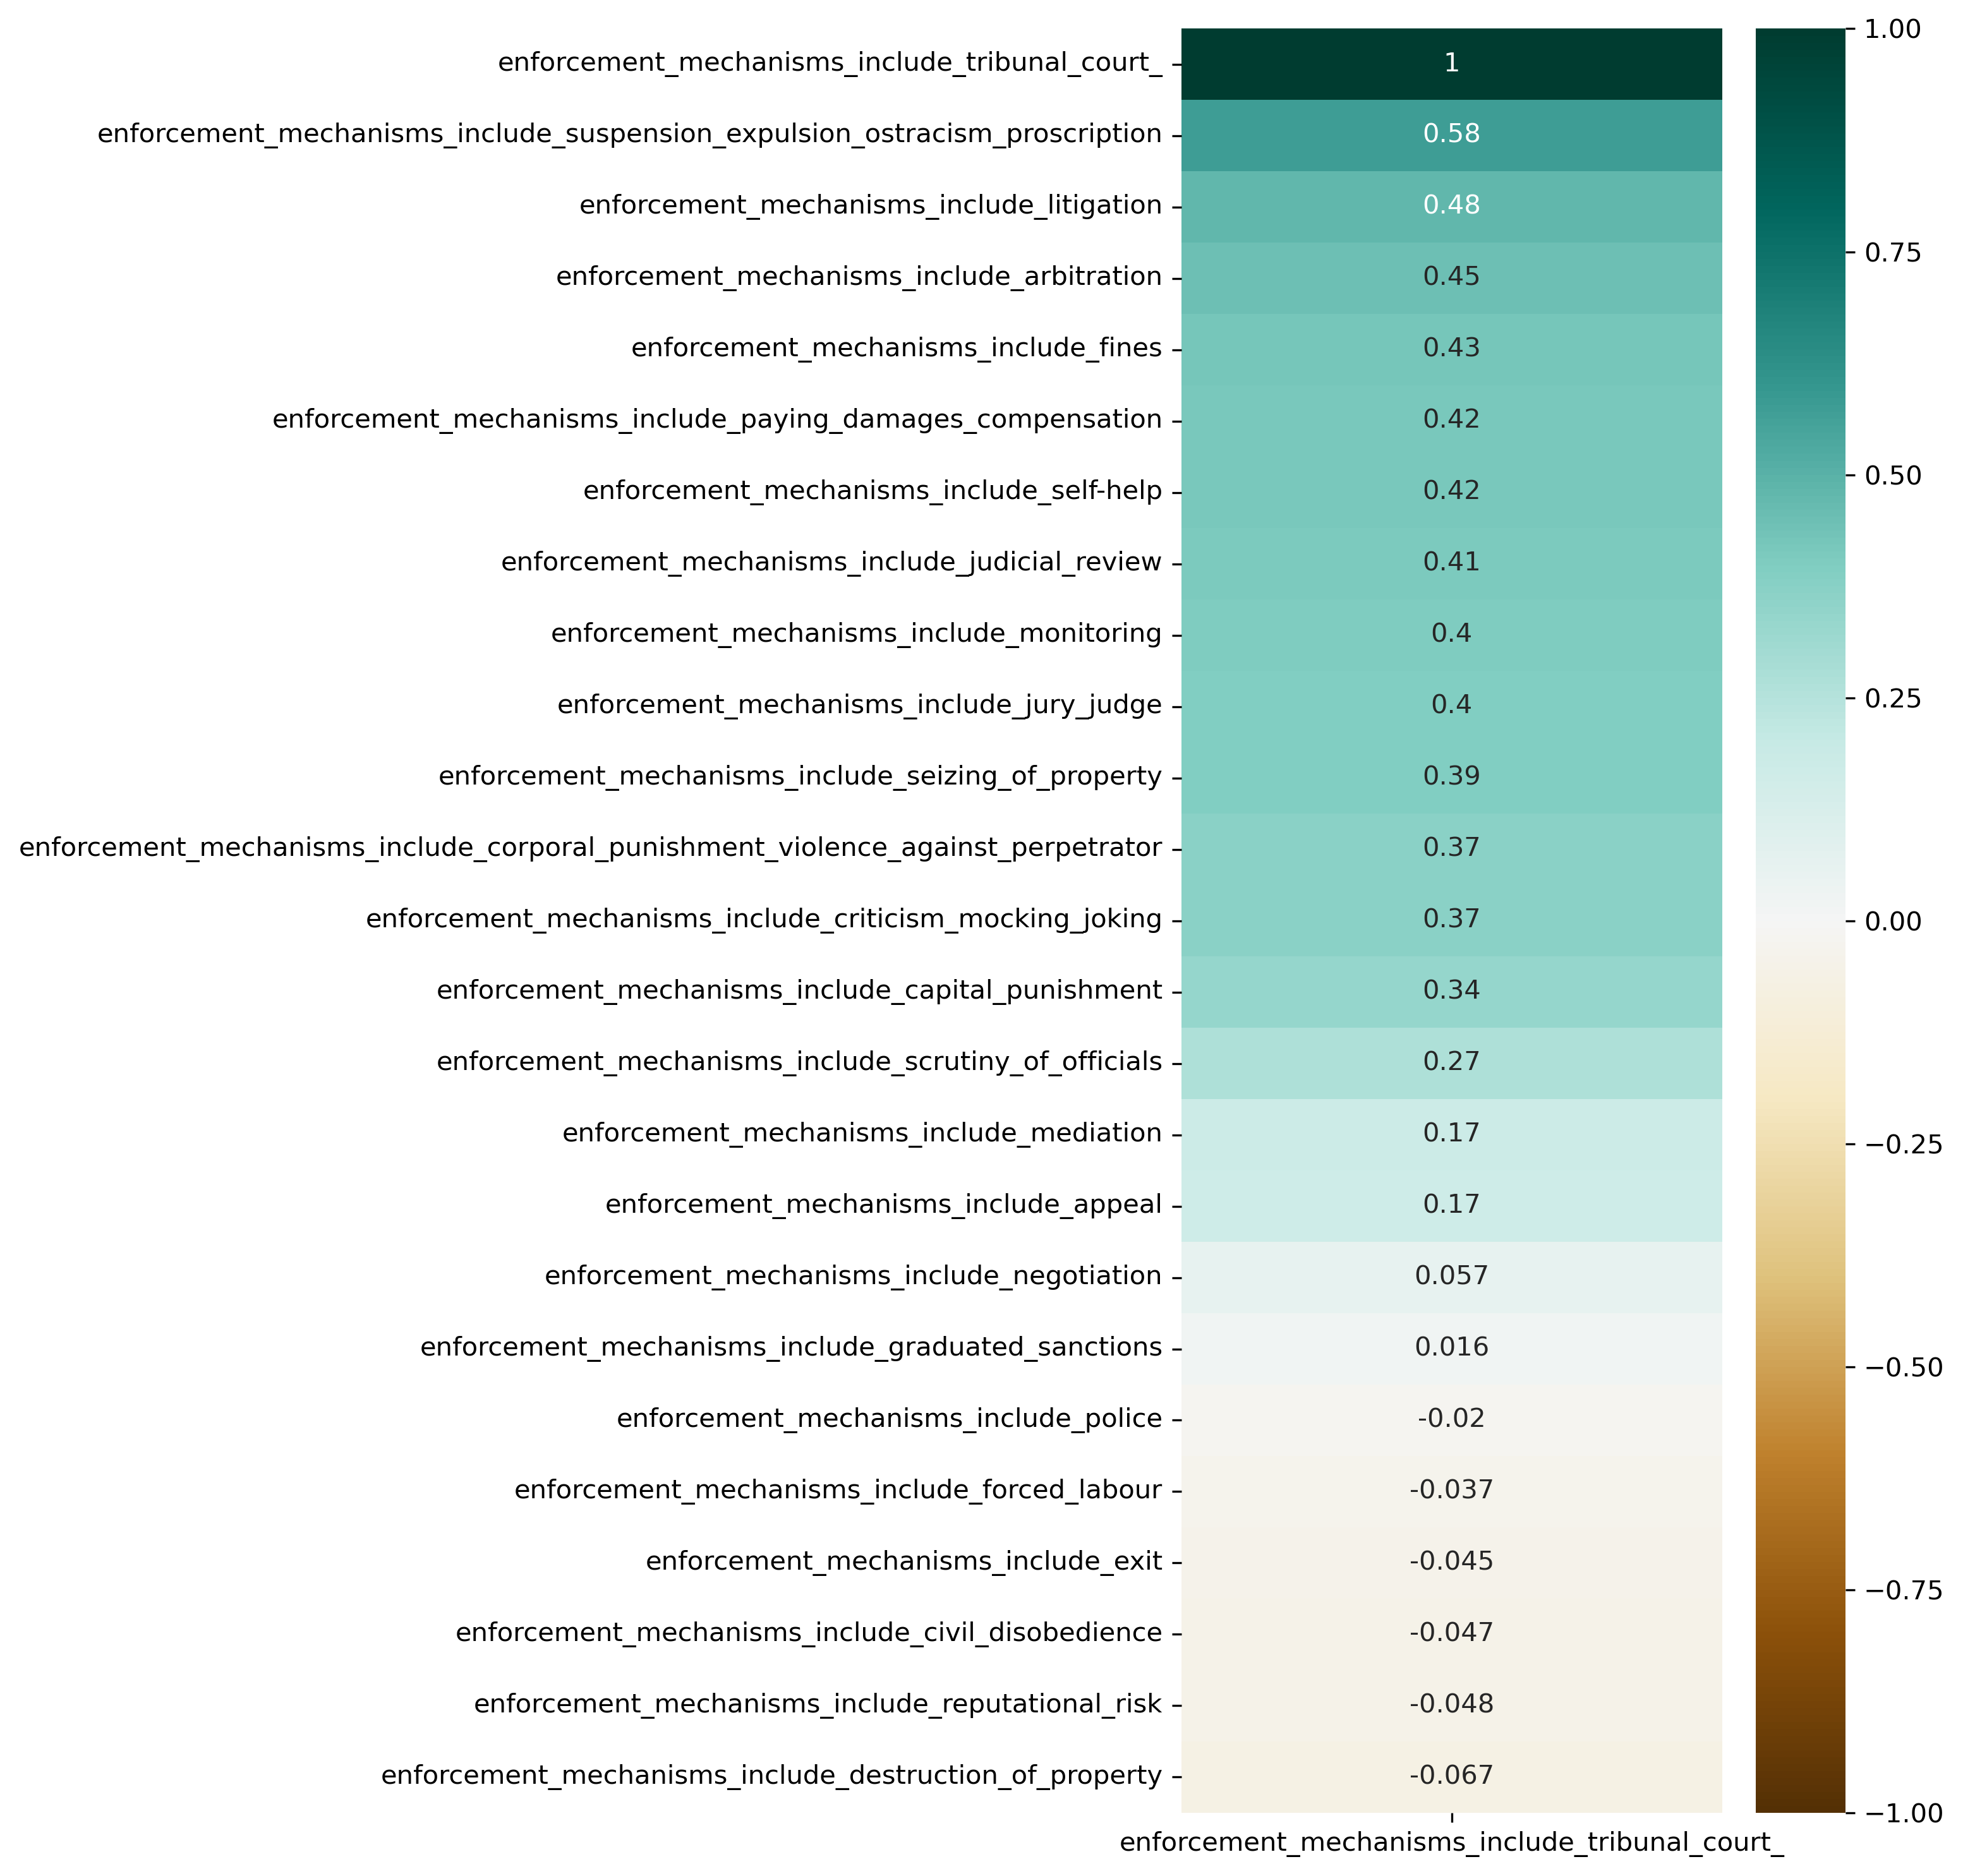

In [35]:
plt.figure(figsize=(10,10))
sns.heatmap(
    enforcement_courts_corr.sort_values(by=courts, ascending=False), 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/enforcement_courts_corr.png')
plt.show()

## Courts Analysis: Size

In [36]:
size_cols = [col for col in col_list if col.startswith('Size:')]
size_cols

['Size: 100 - 1,000',
 'Size: 1,001 - 10,000',
 'Size: 10,001 - 100,000',
 'Size: 100,001 - 1,000,000',
 'Size: 1,000,001 - 10,000,000',
 'Size: 10,000,000+',
 'Size: Unknown']

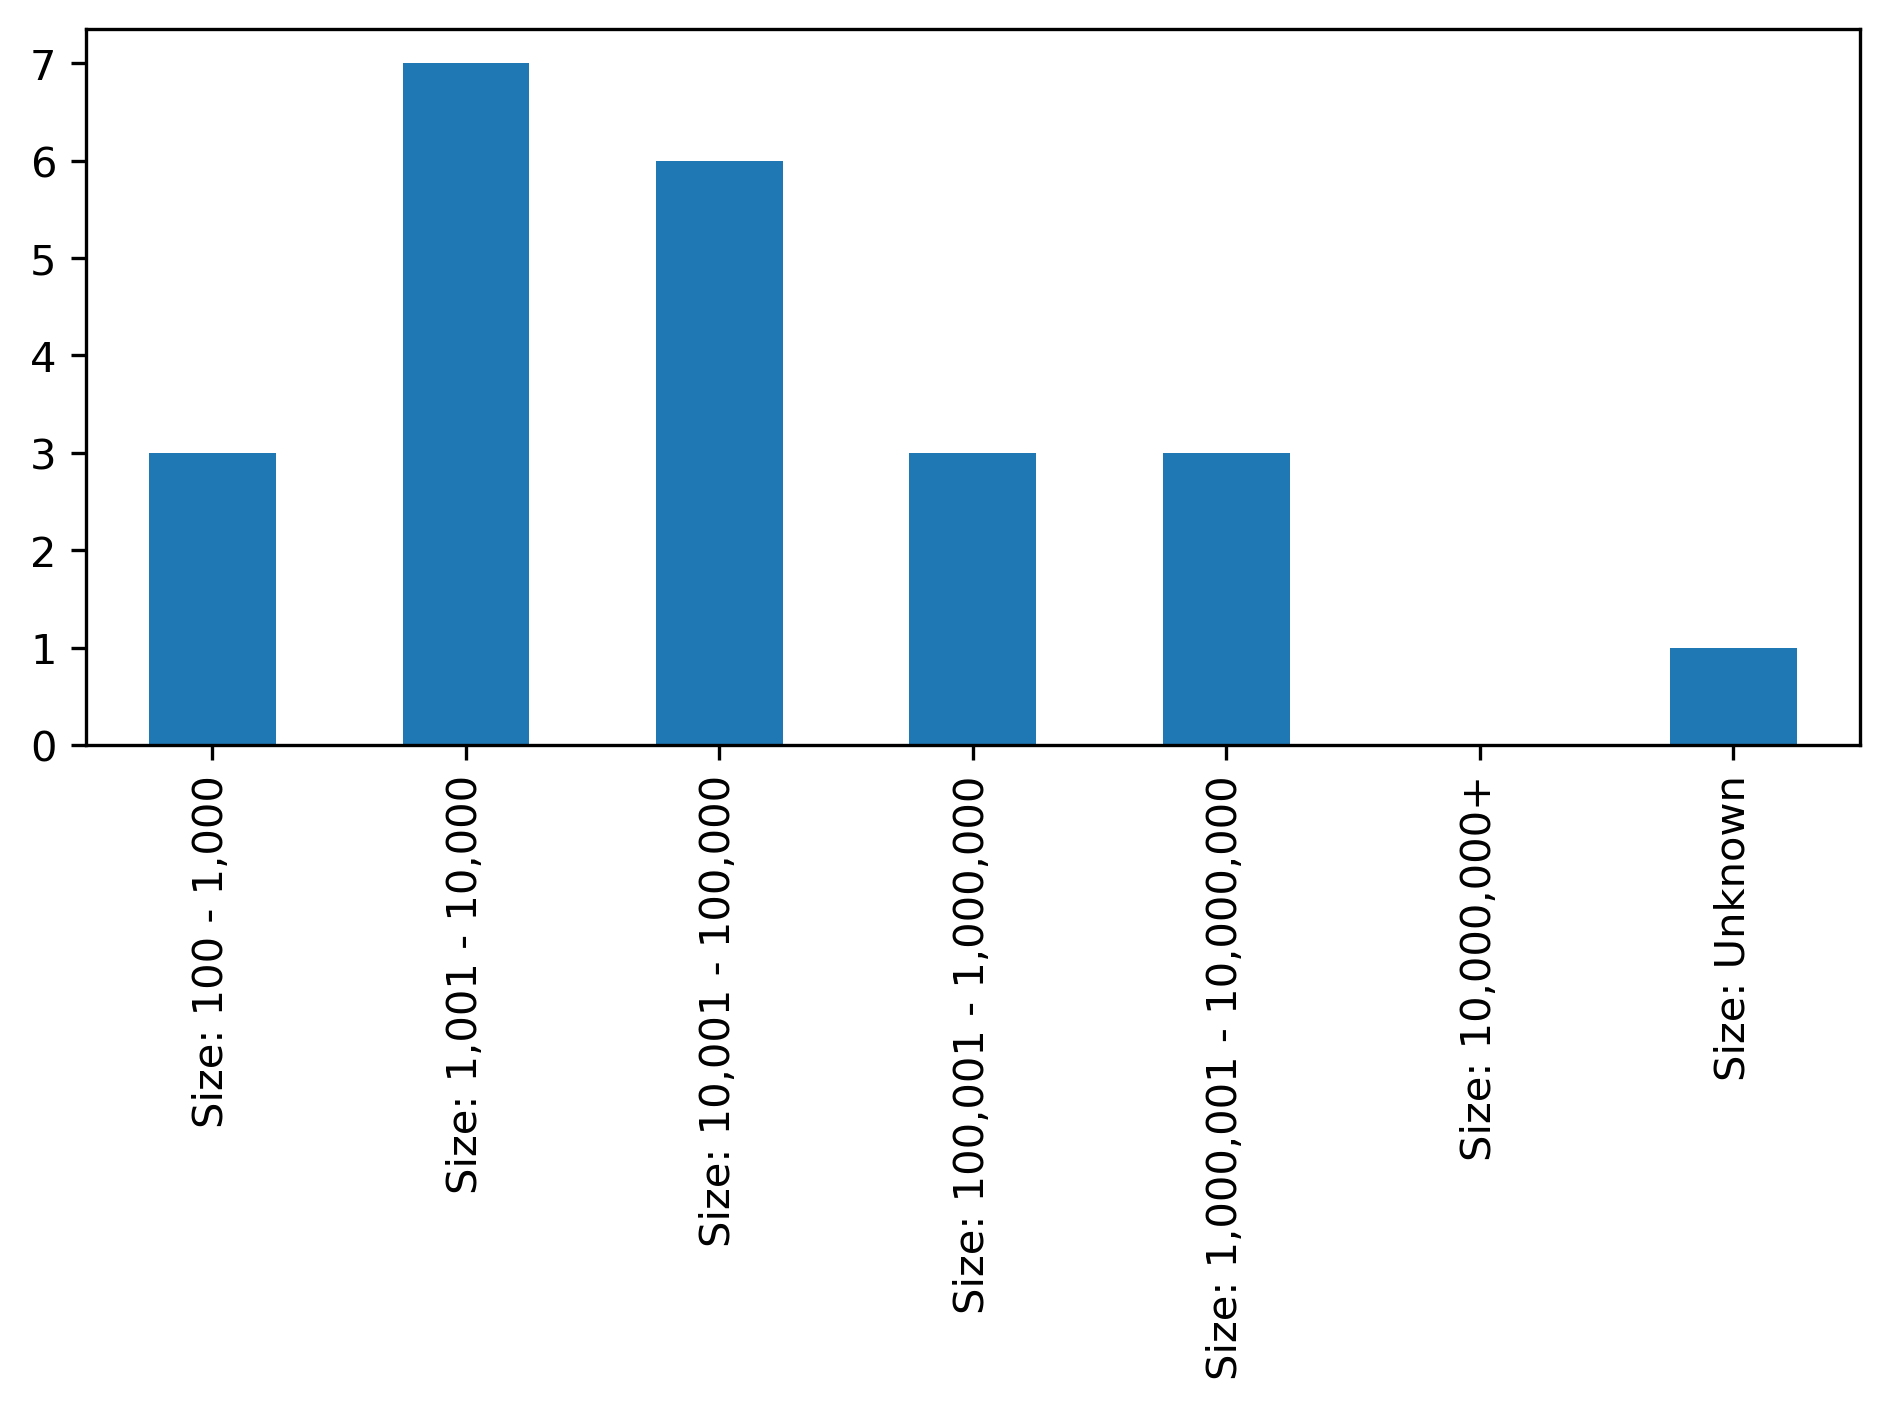

In [37]:
# Size histogram
courts_df[size_cols].sum().plot(kind='bar')

plt.tight_layout()
plt.savefig('../' + DATA_VERSION +  '-fig/fig-courts/courts_size_histogram.png')
plt.show()

In [38]:
size_courts_corr = courts_corr[courts_corr.index.str.startswith('Size:')]

In [39]:
size_courts_corr

,enforcement_mechanisms_include_tribunal_court_
"Size: 100 - 1,000",0.054922
"Size: 1,001 - 10,000",-0.057193
"Size: 10,001 - 100,000",0.064176
"Size: 100,001 - 1,000,000",0.351493
"Size: 1,000,001 - 10,000,000",0.056583
"Size: 10,000,000+",-0.087326
Size: Unknown,-0.086994


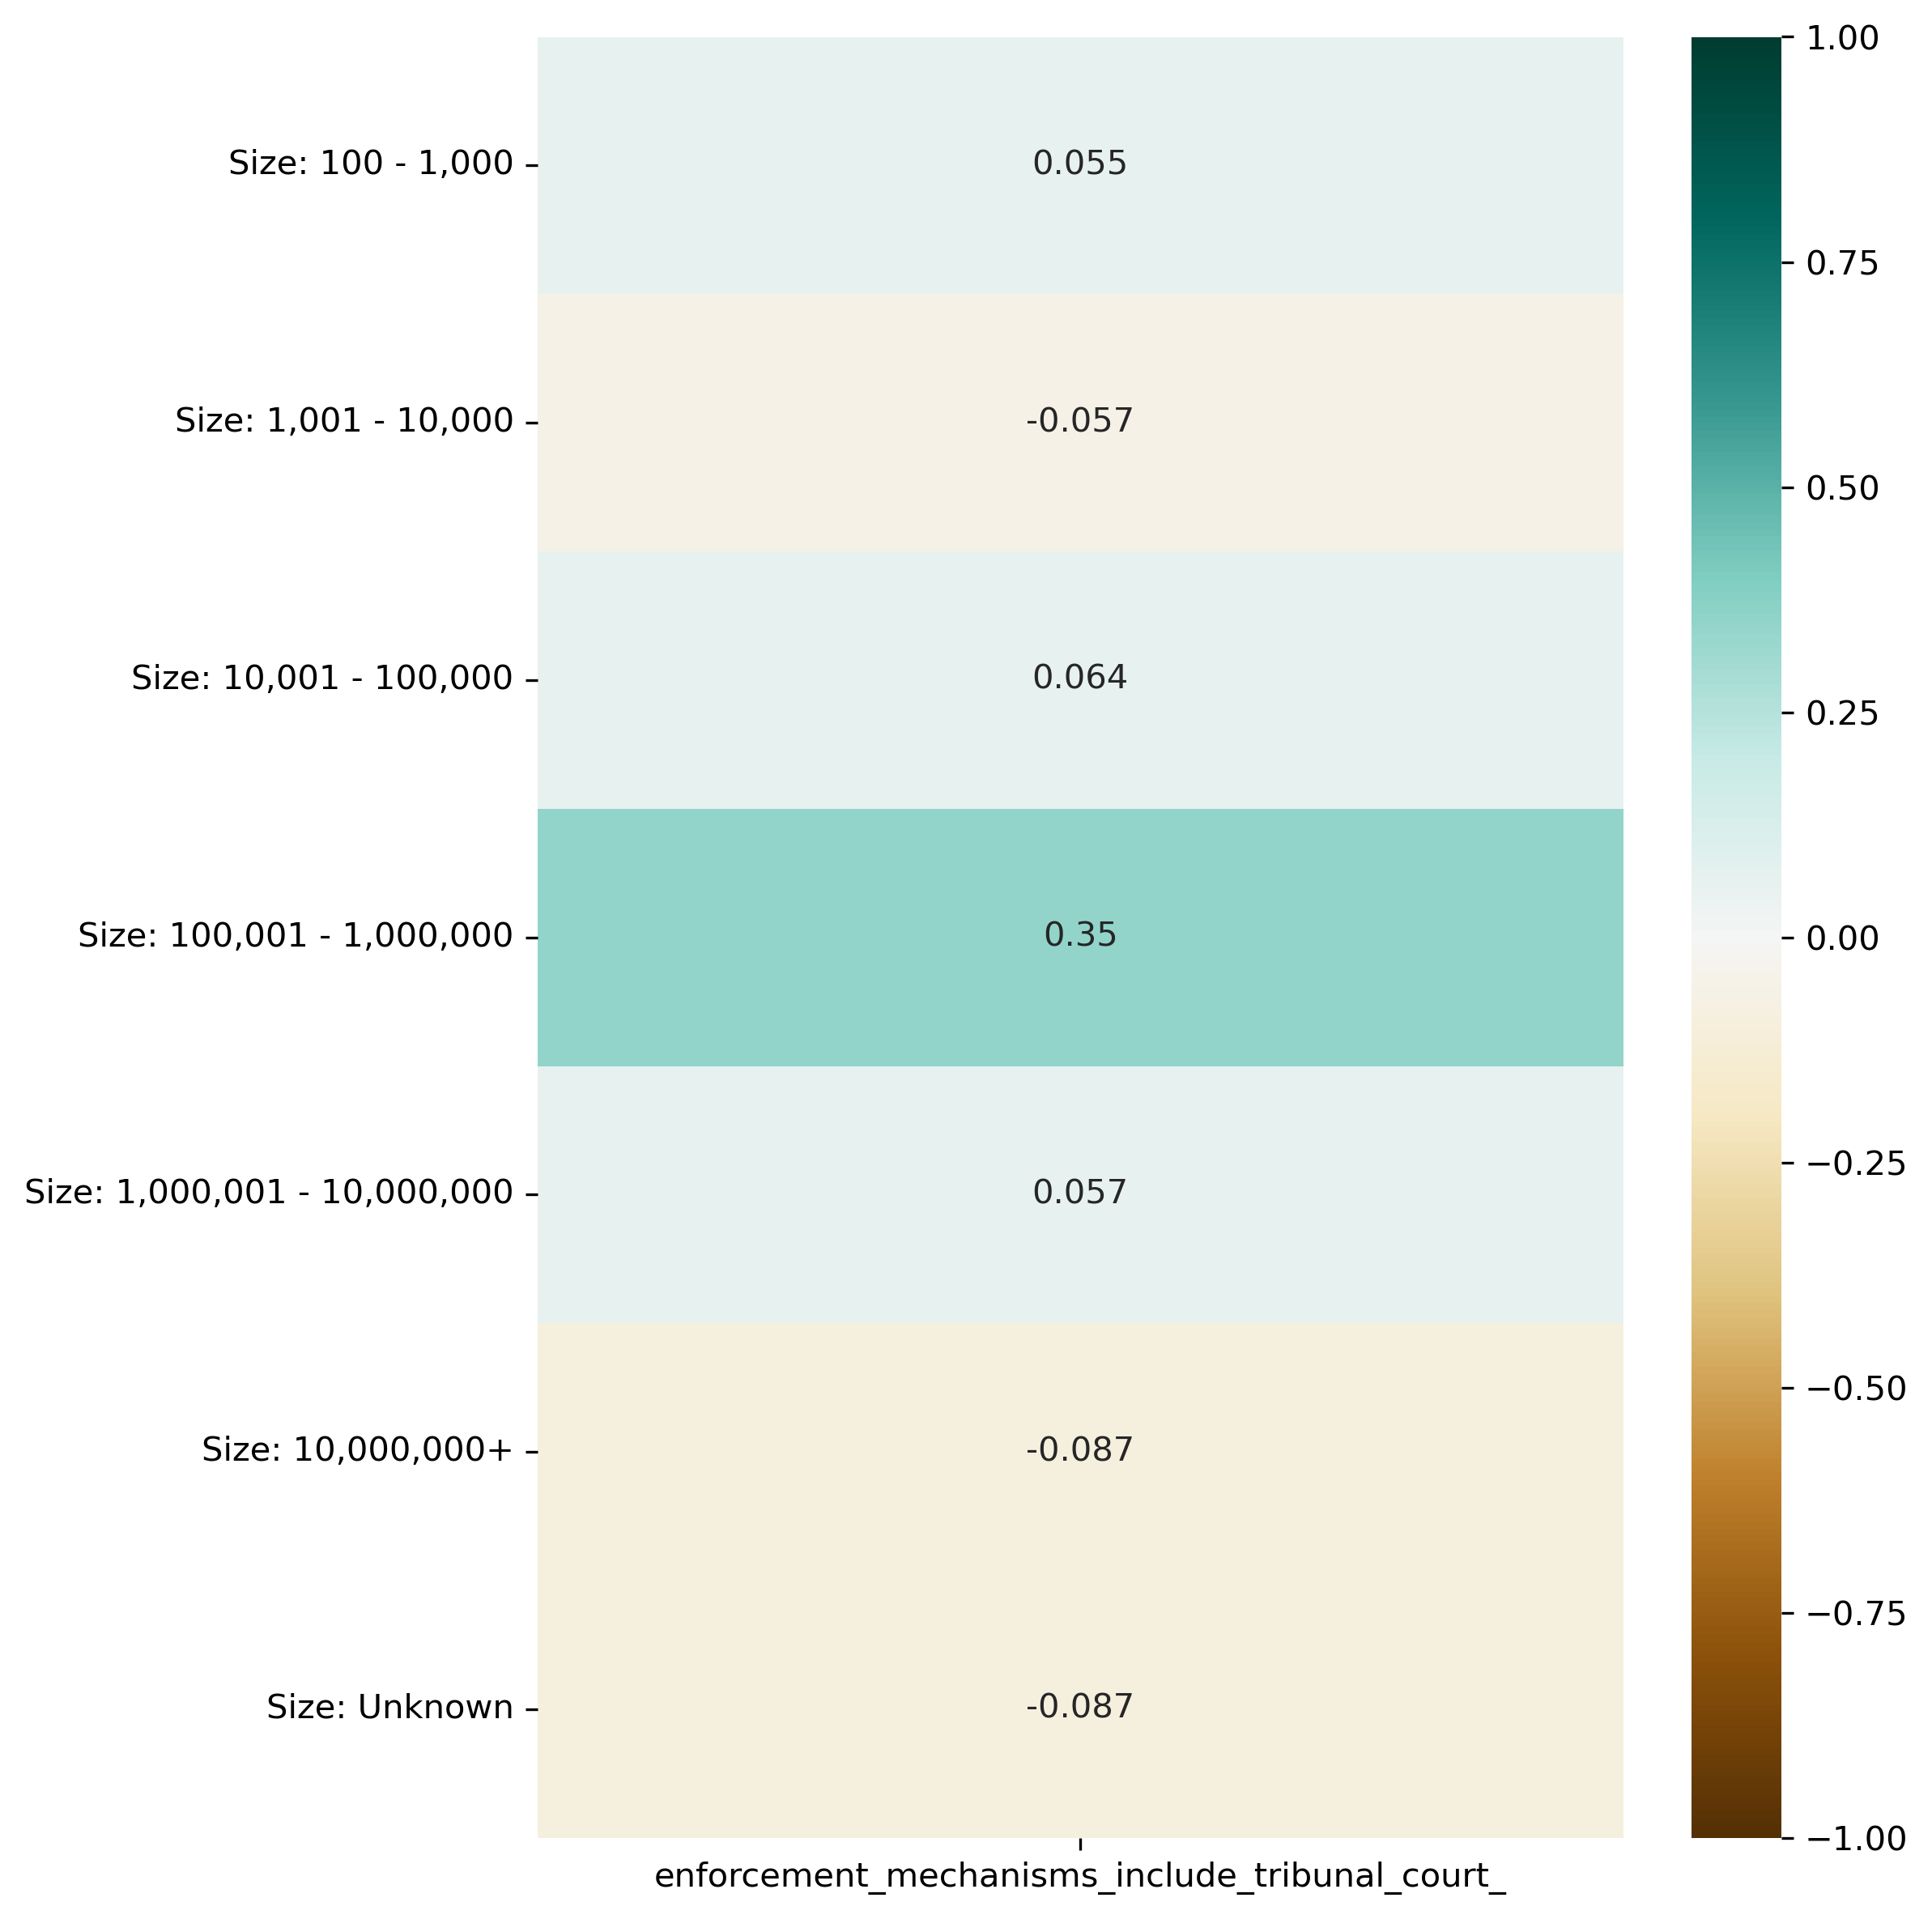

In [40]:
plt.figure(figsize=(8,8))
sns.heatmap(
    size_courts_corr, 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/courts_size_corr.png')
plt.show()

## Councils Analysis: Region

In [41]:
region_cols = [col for col in col_list if col.startswith('Region:')]
region_cols

['Region: Africa',
 'Region: Europe',
 'Region: Asia',
 'Region: Middle East',
 'Region: North America',
 'Region: Central America',
 'Region: South America',
 'Region: Oceania']

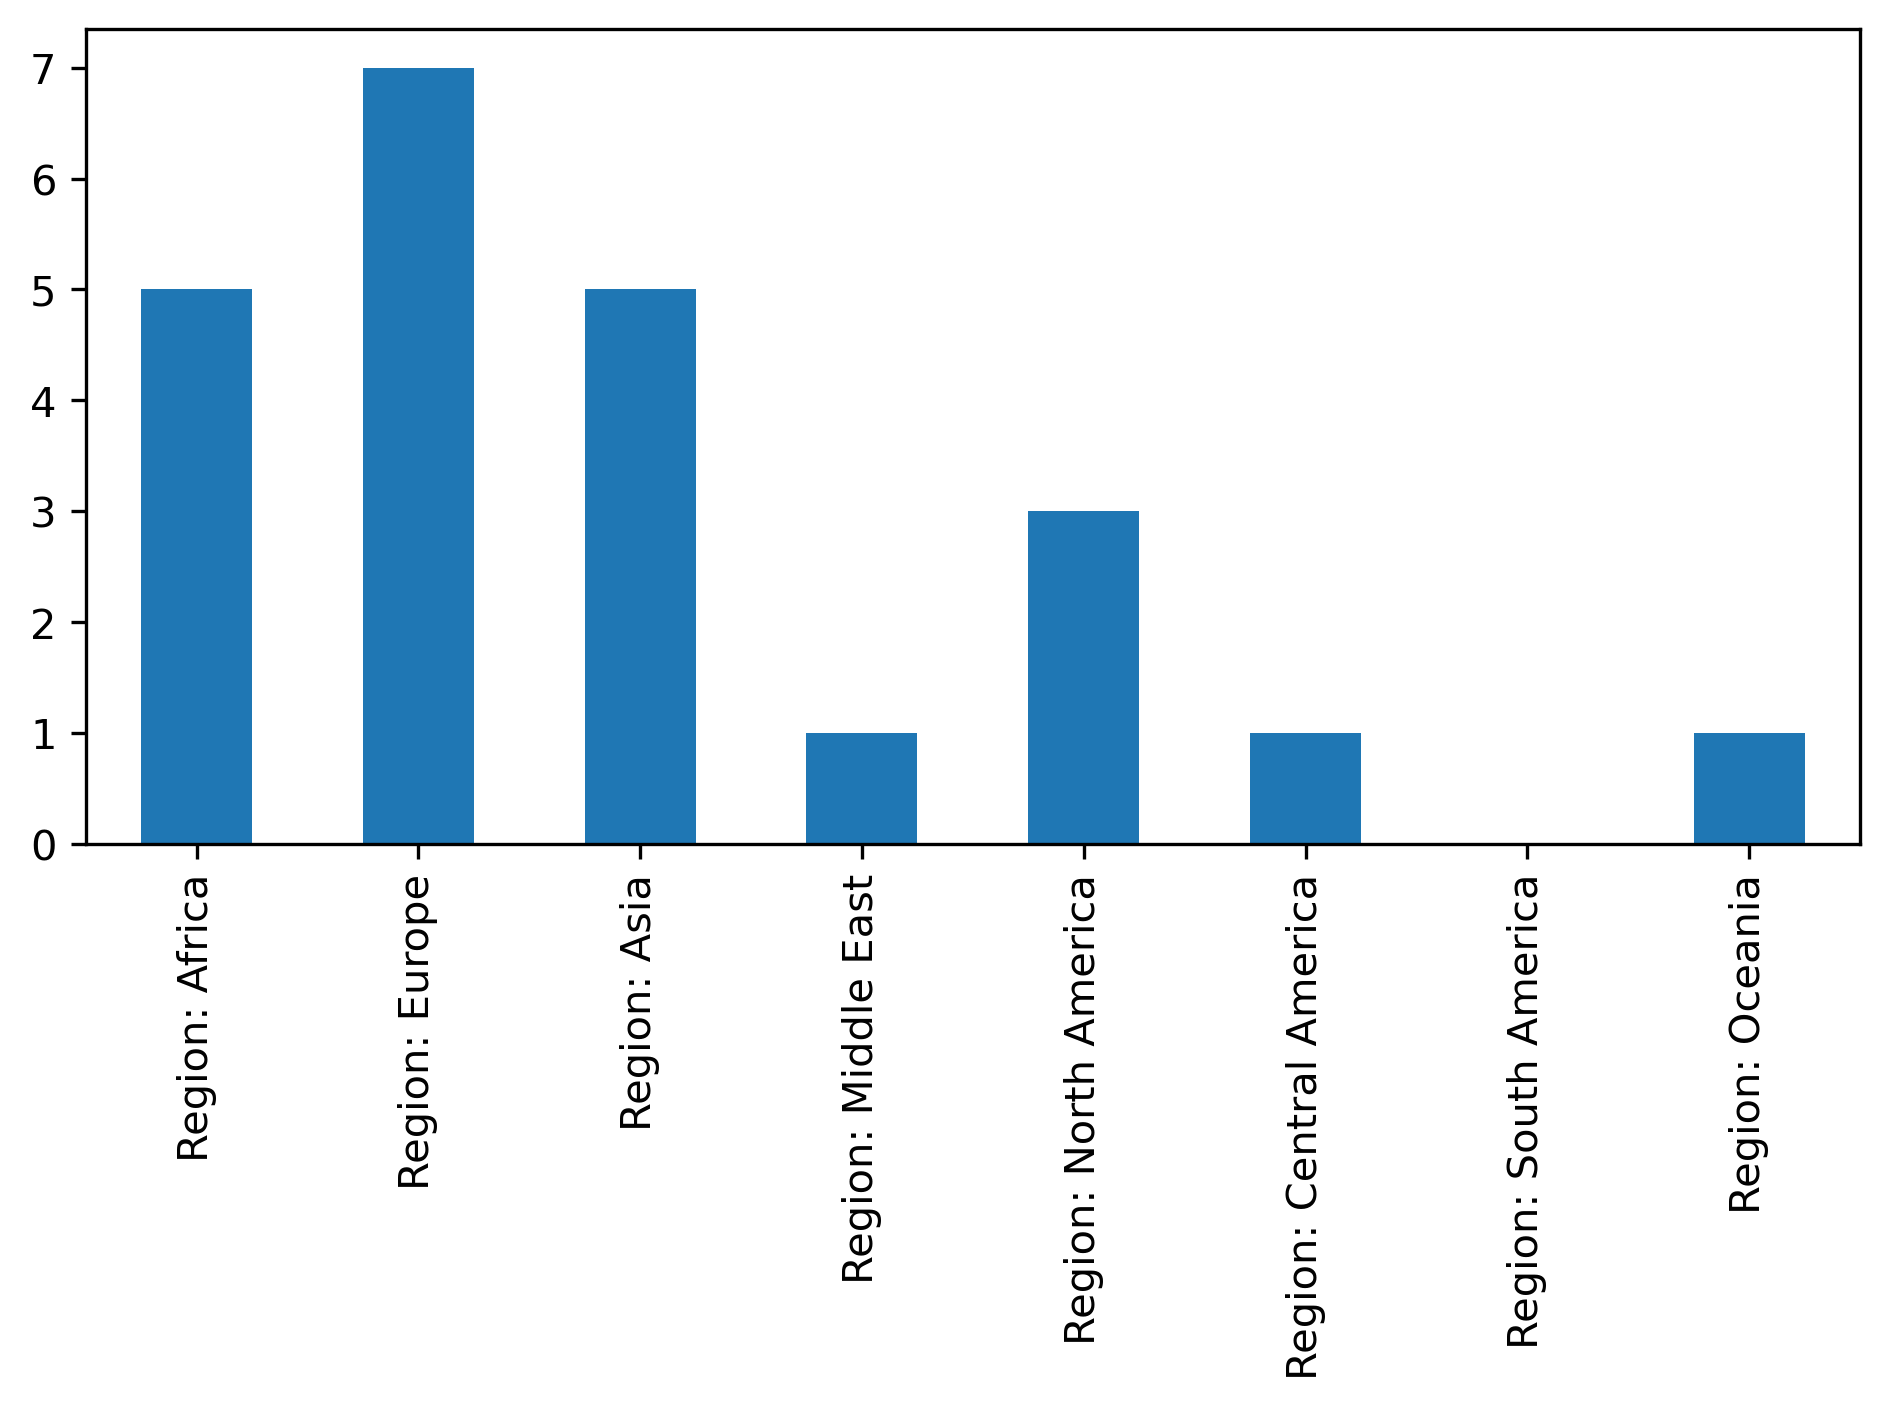

In [42]:
# Region histogram
courts_df[region_cols].sum().plot(kind='bar')

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/courts_region_histogram.png')
plt.show()

In [43]:
region_courts_corr = courts_corr[courts_corr.index.str.startswith('Region:')]

In [44]:
region_courts_corr

,enforcement_mechanisms_include_tribunal_court_
Region: Africa,0.434707
Region: Europe,0.217122
Region: Asia,-0.082373
Region: Middle East,-0.074698
Region: North America,-0.109791
Region: Central America,-0.030112
Region: South America,-0.095191
Region: Oceania,-0.045914


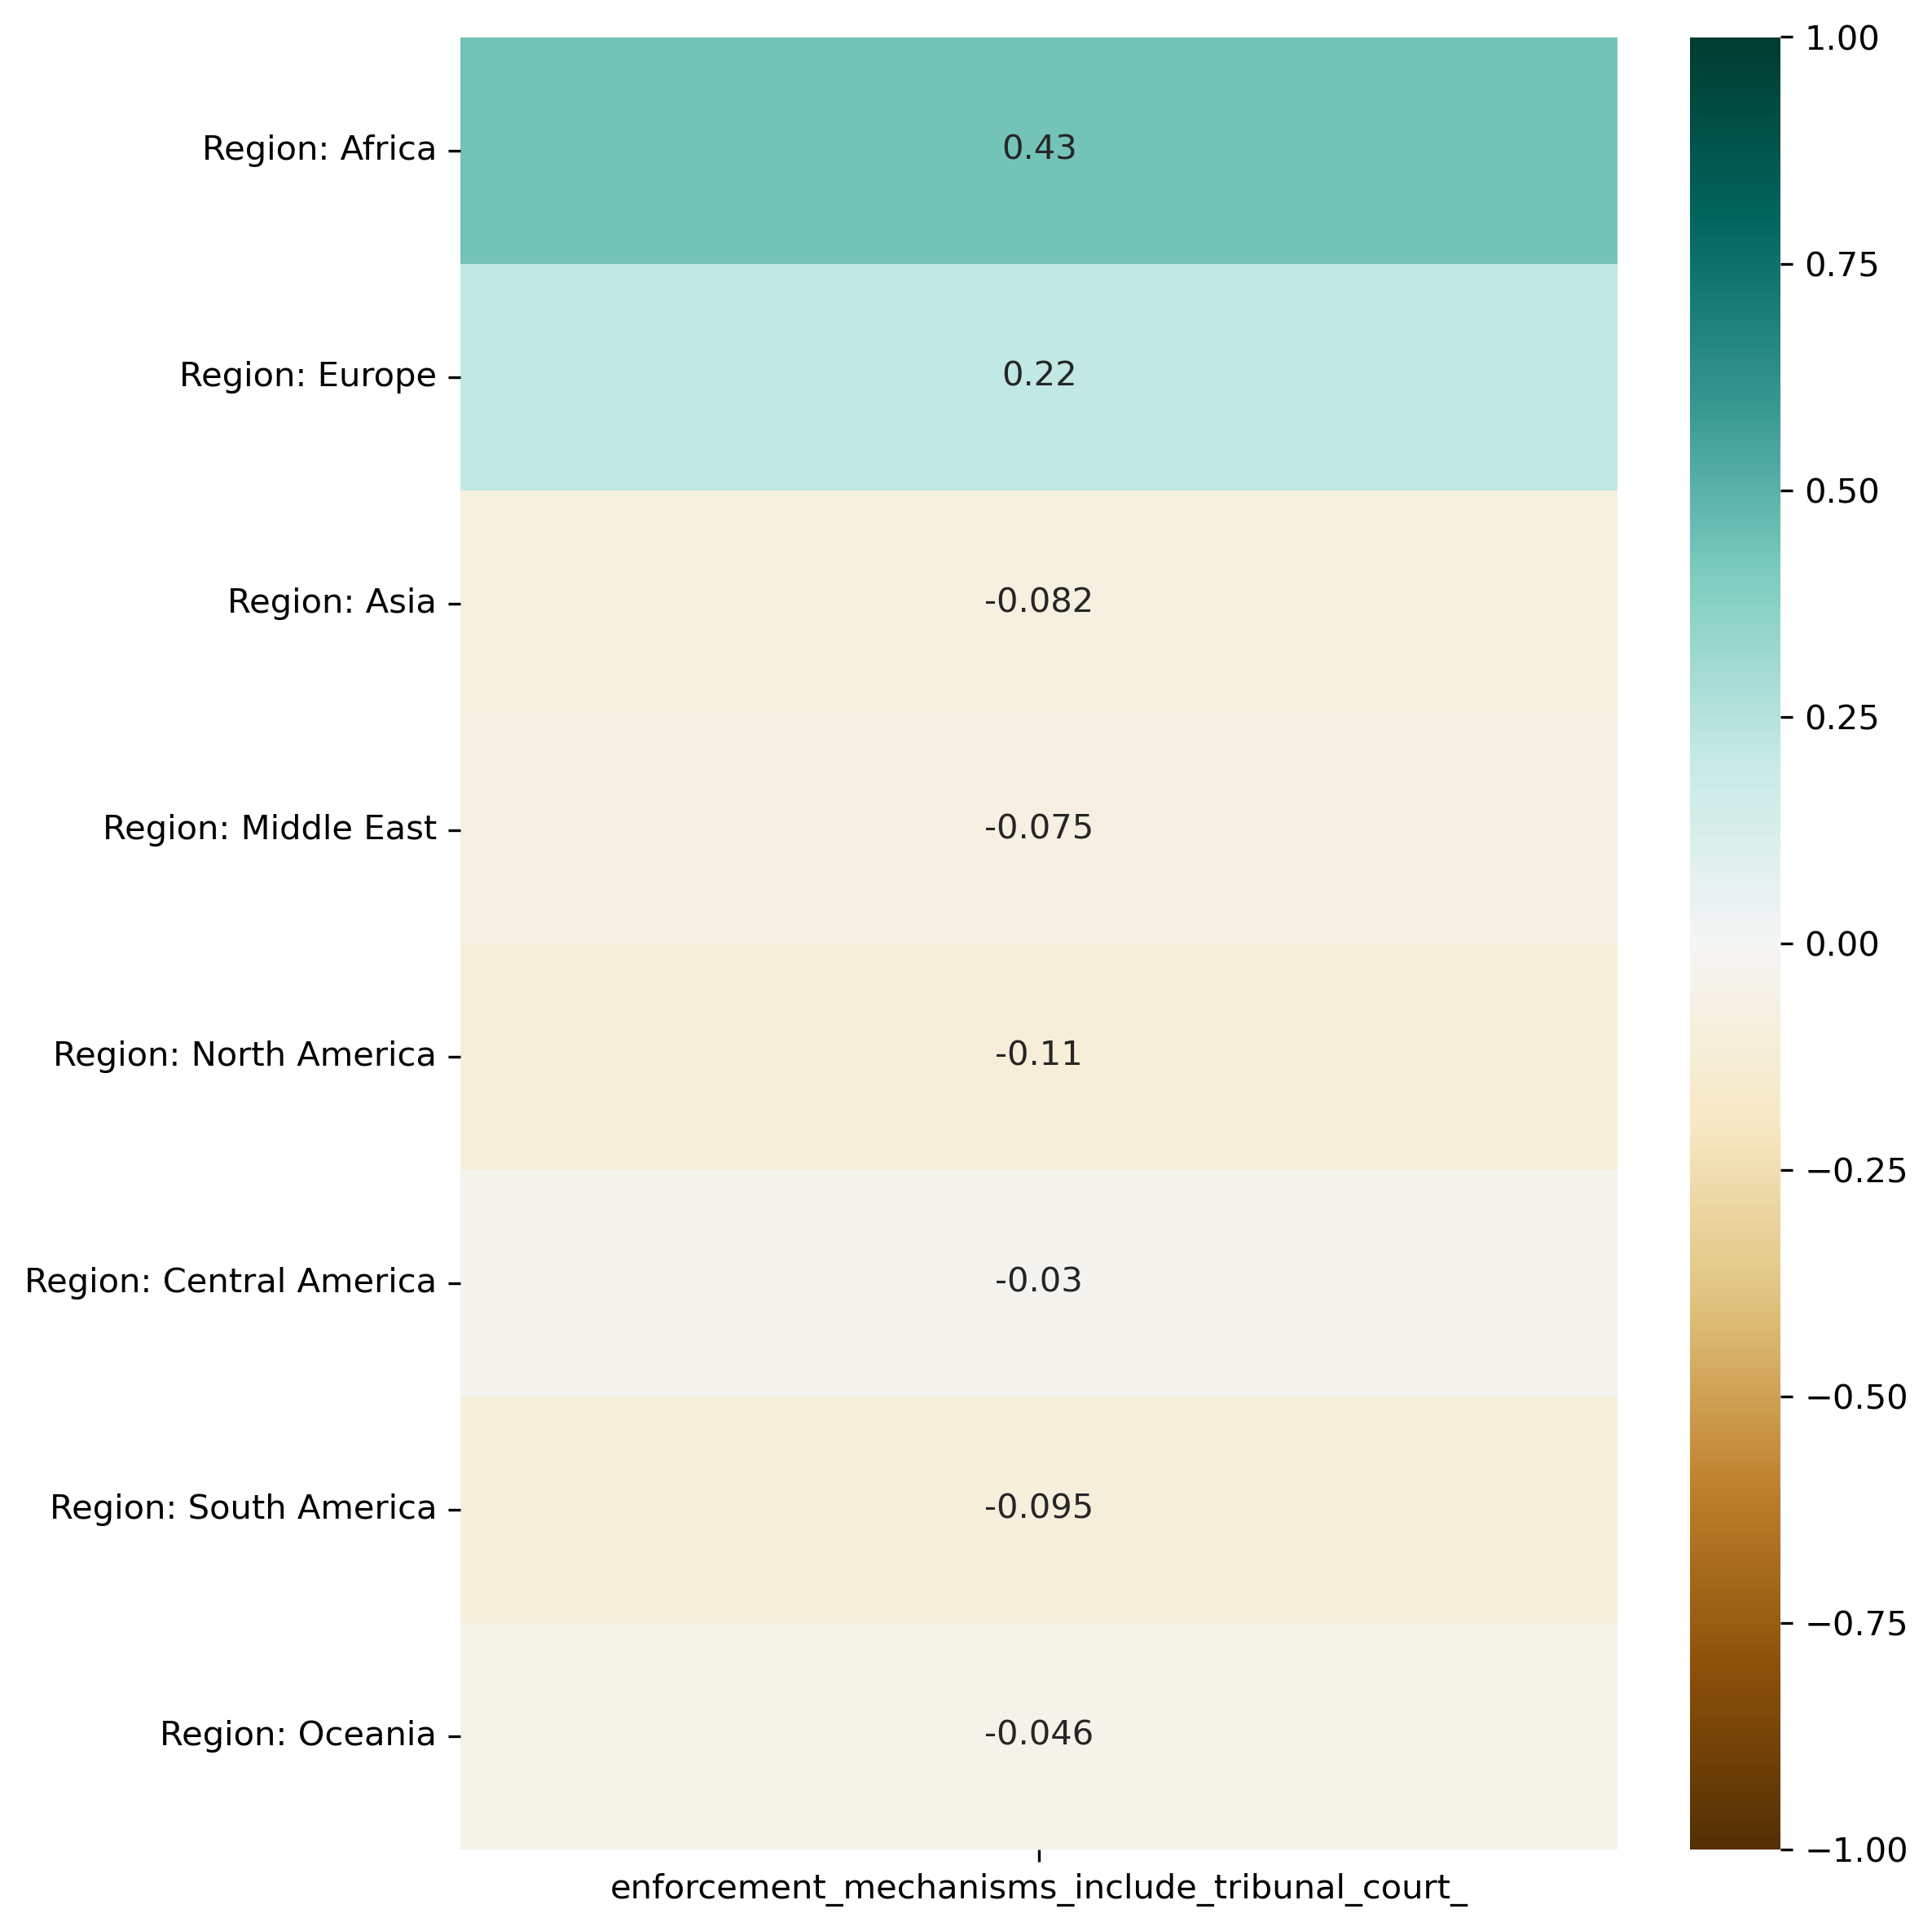

In [45]:
plt.figure(figsize=(8,8))
sns.heatmap(
    region_courts_corr, 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/courts_region_corr.png')
plt.show()

### Mapping council regions

In [46]:
worldmap = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

worldmap.head()

/var/folders/v7/8x_7ty4j3m76hgg7tncks_kc0000gn/T/ipykernel_2860/1532259957.py:1: FutureWarning:

The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.



,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000..."
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((33.90371 -0.95000, 34.07262 -1.05982..."
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742..."
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000..."


In [47]:
central_america_countries = [
    'Belize',
    'Costa Rica',
    'El Salvador',
    'Guatemala',
    'Honduras',
    'Nicaragua',
    'Panama'
]

middle_east_countries = [
    'Cyprus',
    'Egypt',
    'Iran',
    'Iraq',
    'Israel',
    'Jordan',
    'Kuwait',
    'Lebanon',
    'Oman',
    'Palestine',
    'Qatar',
    'Saudi Arabia',
    'Syria',
    'Turkey',
    'United Arab Emirates',
    'Yemen'
]

# Add region for Central America
worldmap.loc[(worldmap['name'].isin(central_america_countries)), 'continent'] = 'Central America'

# Add region for Middle East
worldmap.loc[(worldmap['name'].isin(middle_east_countries)), 'continent'] = 'Middle East'

worldmap['continent'].value_counts()

continent
Africa                     50
Europe                     39
Asia                       32
Middle East                16
South America              13
North America              11
Oceania                     7
Central America             7
Seven seas (open ocean)     1
Antarctica                  1
Name: count, dtype: int64

In [48]:
region_map = gpd.GeoDataFrame(columns=['Region', 'geometry'])
regions_list = list(gov_df['Region'].unique())

In [49]:
region_map['Region'] = regions_list

region_map['geometry'].loc[region_map['Region'] == 'Africa'] = worldmap.loc[(worldmap['continent'] == 'Africa')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Europe'] = worldmap.loc[(worldmap['continent'] == 'Europe')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Asia'] = worldmap.loc[(worldmap['continent'] == 'Asia')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Middle East'] = worldmap.loc[(worldmap['continent'] == 'Middle East')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'North America'] = worldmap.loc[(worldmap['continent'] == 'North America')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Central America'] = worldmap.loc[(worldmap['continent'] == 'Central America')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'South America'] = worldmap.loc[(worldmap['continent'] == 'South America')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Oceania'] = worldmap.loc[(worldmap['continent'] == 'Oceania')].unary_union

region_map

/var/folders/v7/8x_7ty4j3m76hgg7tncks_kc0000gn/T/ipykernel_2860/454843215.py:3: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/var/folders/v7/8x_7ty4j3m76hgg7tncks_kc0000gn/T/ipykernel_2860/454843215.py:4: FutureWarning:

ChainedAssignmentEr

,Region,geometry
0,Europe,"MULTIPOLYGON (((-53.555 2.335, -53.779 2.377, ..."
1,Asia,"MULTIPOLYGON (((105.857 -4.306, 105.818 -5.852..."
2,Middle East,"MULTIPOLYGON (((25.000 25.682, 25.000 29.239, ..."
3,Central America,"POLYGON ((-77.243 7.935, -77.431 7.638, -77.75..."
4,Africa,"MULTIPOLYGON (((-11.439 6.786, -11.708 6.860, ..."
5,North America,"MULTIPOLYGON (((-155.222 19.240, -155.542 19.0..."
6,South America,"MULTIPOLYGON (((-68.640 -55.580, -69.232 -55.4..."
7,Oceania,"MULTIPOLYGON (((147.914 -43.212, 147.565 -42.9..."


#### All Councils

In [50]:
courts_region_map = region_map

In [51]:
courts_region_counts = courts_df['Region'].value_counts().rename_axis('Region').reset_index(name='Count')

In [52]:
courts_region_counts

,Region,Count
0,Europe,7
1,Africa,5
2,Asia,5
3,North America,3
4,Middle East,1
5,Central America,1
6,Oceania,1


In [53]:
# Custom: Add empty regions
missing_regions_df = pd.DataFrame([['South America', 0],['North America', 0]], columns=['Region', 'Count'])
missing_regions_df

,Region,Count
0,South America,0
1,North America,0


In [54]:
# Custom: Add empty regions
courts_region_counts = pd.concat([courts_region_counts, missing_regions_df])
courts_region_counts

,Region,Count
0,Europe,7
1,Africa,5
2,Asia,5
3,North America,3
4,Middle East,1
5,Central America,1
6,Oceania,1
0,South America,0
1,North America,0


In [55]:
all_merged_regions = pd.merge(courts_region_map, courts_region_counts, on='Region')

In [56]:
all_merged_regions

,Region,geometry,Count
0,Europe,"MULTIPOLYGON (((-53.555 2.335, -53.779 2.377, ...",7
1,Asia,"MULTIPOLYGON (((105.857 -4.306, 105.818 -5.852...",5
2,Middle East,"MULTIPOLYGON (((25.000 25.682, 25.000 29.239, ...",1
3,Central America,"POLYGON ((-77.243 7.935, -77.431 7.638, -77.75...",1
4,Africa,"MULTIPOLYGON (((-11.439 6.786, -11.708 6.860, ...",5
5,North America,"MULTIPOLYGON (((-155.222 19.240, -155.542 19.0...",3
6,North America,"MULTIPOLYGON (((-155.222 19.240, -155.542 19.0...",0
7,South America,"MULTIPOLYGON (((-68.640 -55.580, -69.232 -55.4...",0
8,Oceania,"MULTIPOLYGON (((147.914 -43.212, 147.565 -42.9...",1


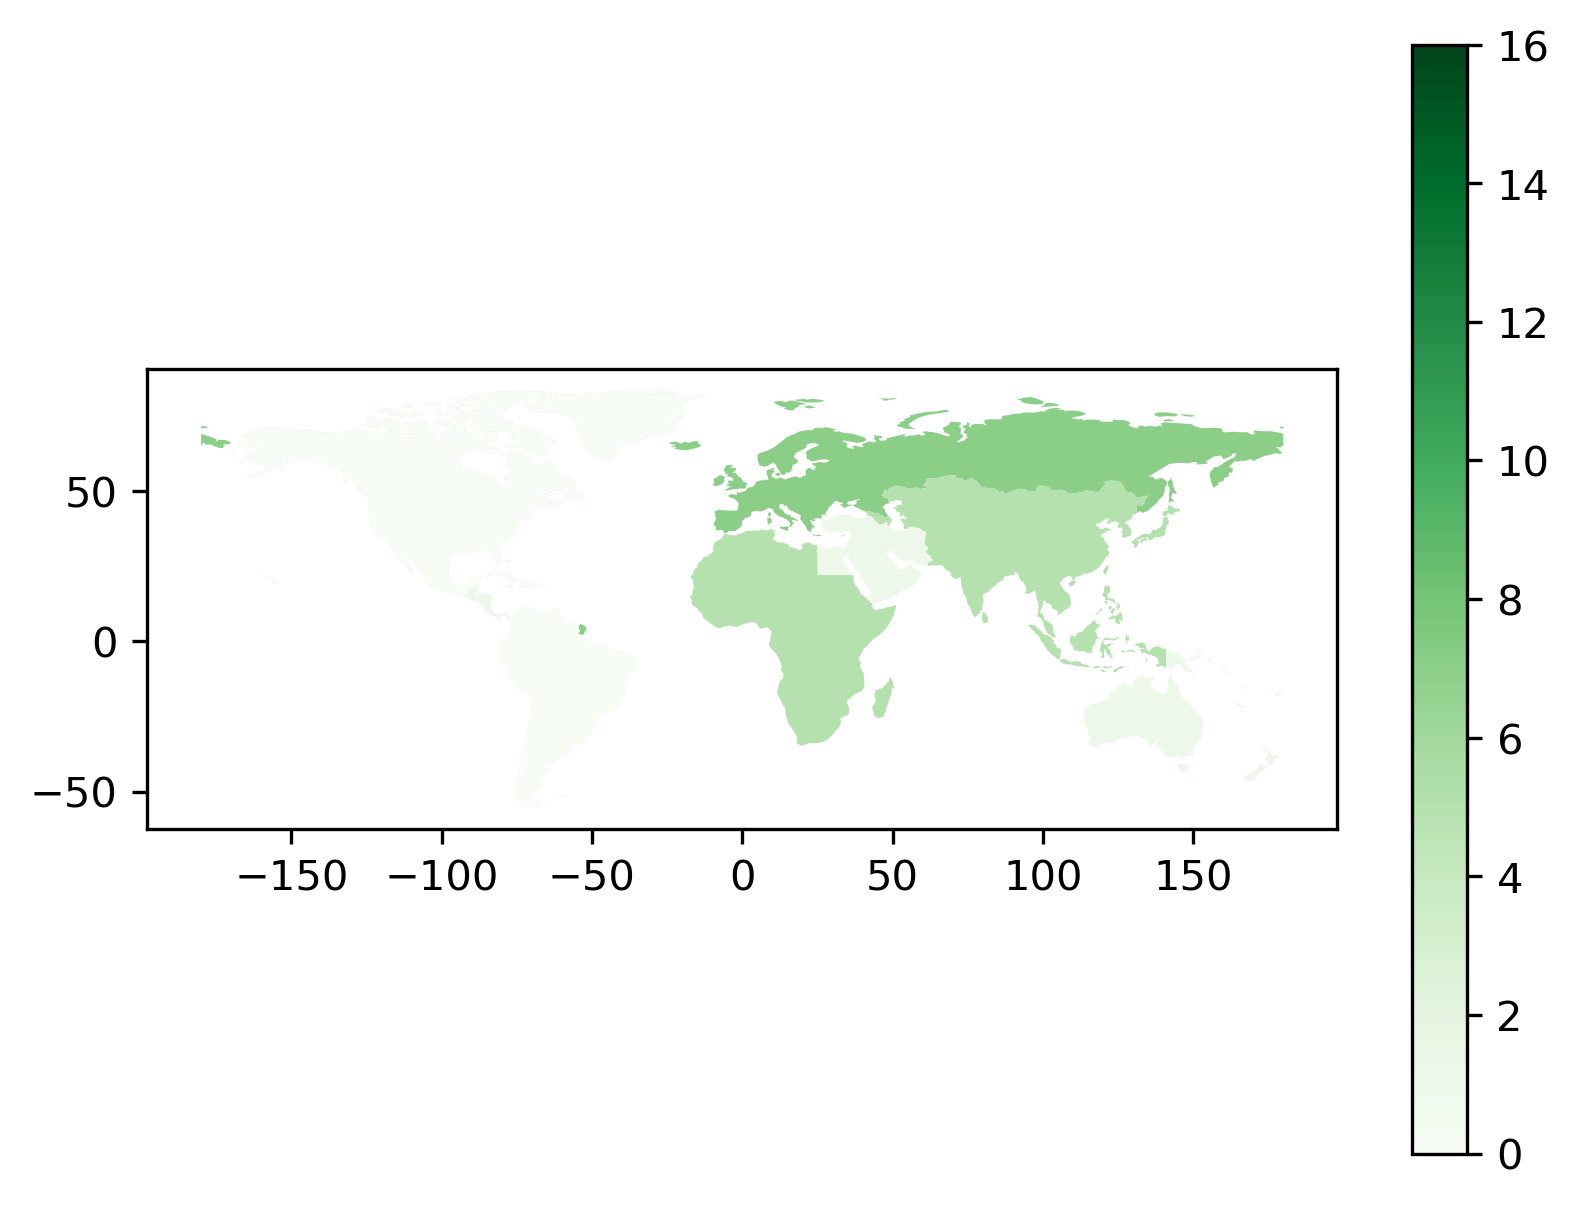

In [57]:
all_merged_regions.plot(
    column='Count', 
    legend=True,
    cmap='Greens',
    vmin=0,
    vmax=16
)

plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/map_courts_all.png')
plt.show()

## Courts Analysis: Timeline 

In [58]:
courts_dates_df = courts_df[['Time span: Start', 'Time span: Duration', 'Name'] + court_col]

In [59]:
courts_dates_df

,Time span: Start,Time span: Duration,Name,enforcement_mechanisms_include_tribunal_court_
4,-1920,120,Assur,1
5,-508,186,Athens (Classical Period),1
8,-400,300,Carthage,1
13,900,300,Communes (Medieval Europe),1
16,-2700,1700,Egypt,1
17,400,700,England (Anglo Saxon),1
22,-480,453,Greek oligarchies,1
26,930,332,Iceland,1
27,900,660,Igbo People,1
34,1800,100,Kachin gumlao,1


In [60]:
courts_dates_tuples = [tuple(x) for x in courts_dates_df.to_numpy()]
courts_dates_tuples

[(-1920, 120, 'Assur', 1),
 (-508, 186, 'Athens (Classical Period)', 1),
 (-400, 300, 'Carthage', 1),
 (900, 300, 'Communes (Medieval Europe)', 1),
 (-2700, 1700, 'Egypt ', 1),
 (400, 700, 'England (Anglo Saxon)', 1),
 (-480, 453, 'Greek oligarchies', 1),
 (930, 332, 'Iceland ', 1),
 (900, 660, 'Igbo People', 1),
 (1800, 100, 'Kachin gumlao', 1),
 (1900, 123, 'Kung San (Ju/hoansi)', 1),
 (1800, 100, 'Minangkabau', 1),
 (-1894, 299, 'Sippar', 1),
 (1300, 500, 'Switzerland', 1),
 (1100, 500, 'Tlaxcala', 1),
 (1400, 500, 'Gilbertese', 1),
 (1800, 100, 'Toda', 1),
 (1600, 350, 'Nicobarese', 1),
 (1600, 200, 'Gilyak (Nivkh)', 1),
 (1800, 100, 'Nama', 1),
 (1800, 100, "Ingalik [Deg Xit'an]", 1),
 (1700, 200, 'Kutenai', 1),
 (1500, 500, "Micmac [Mi'kmaq]", 1)]

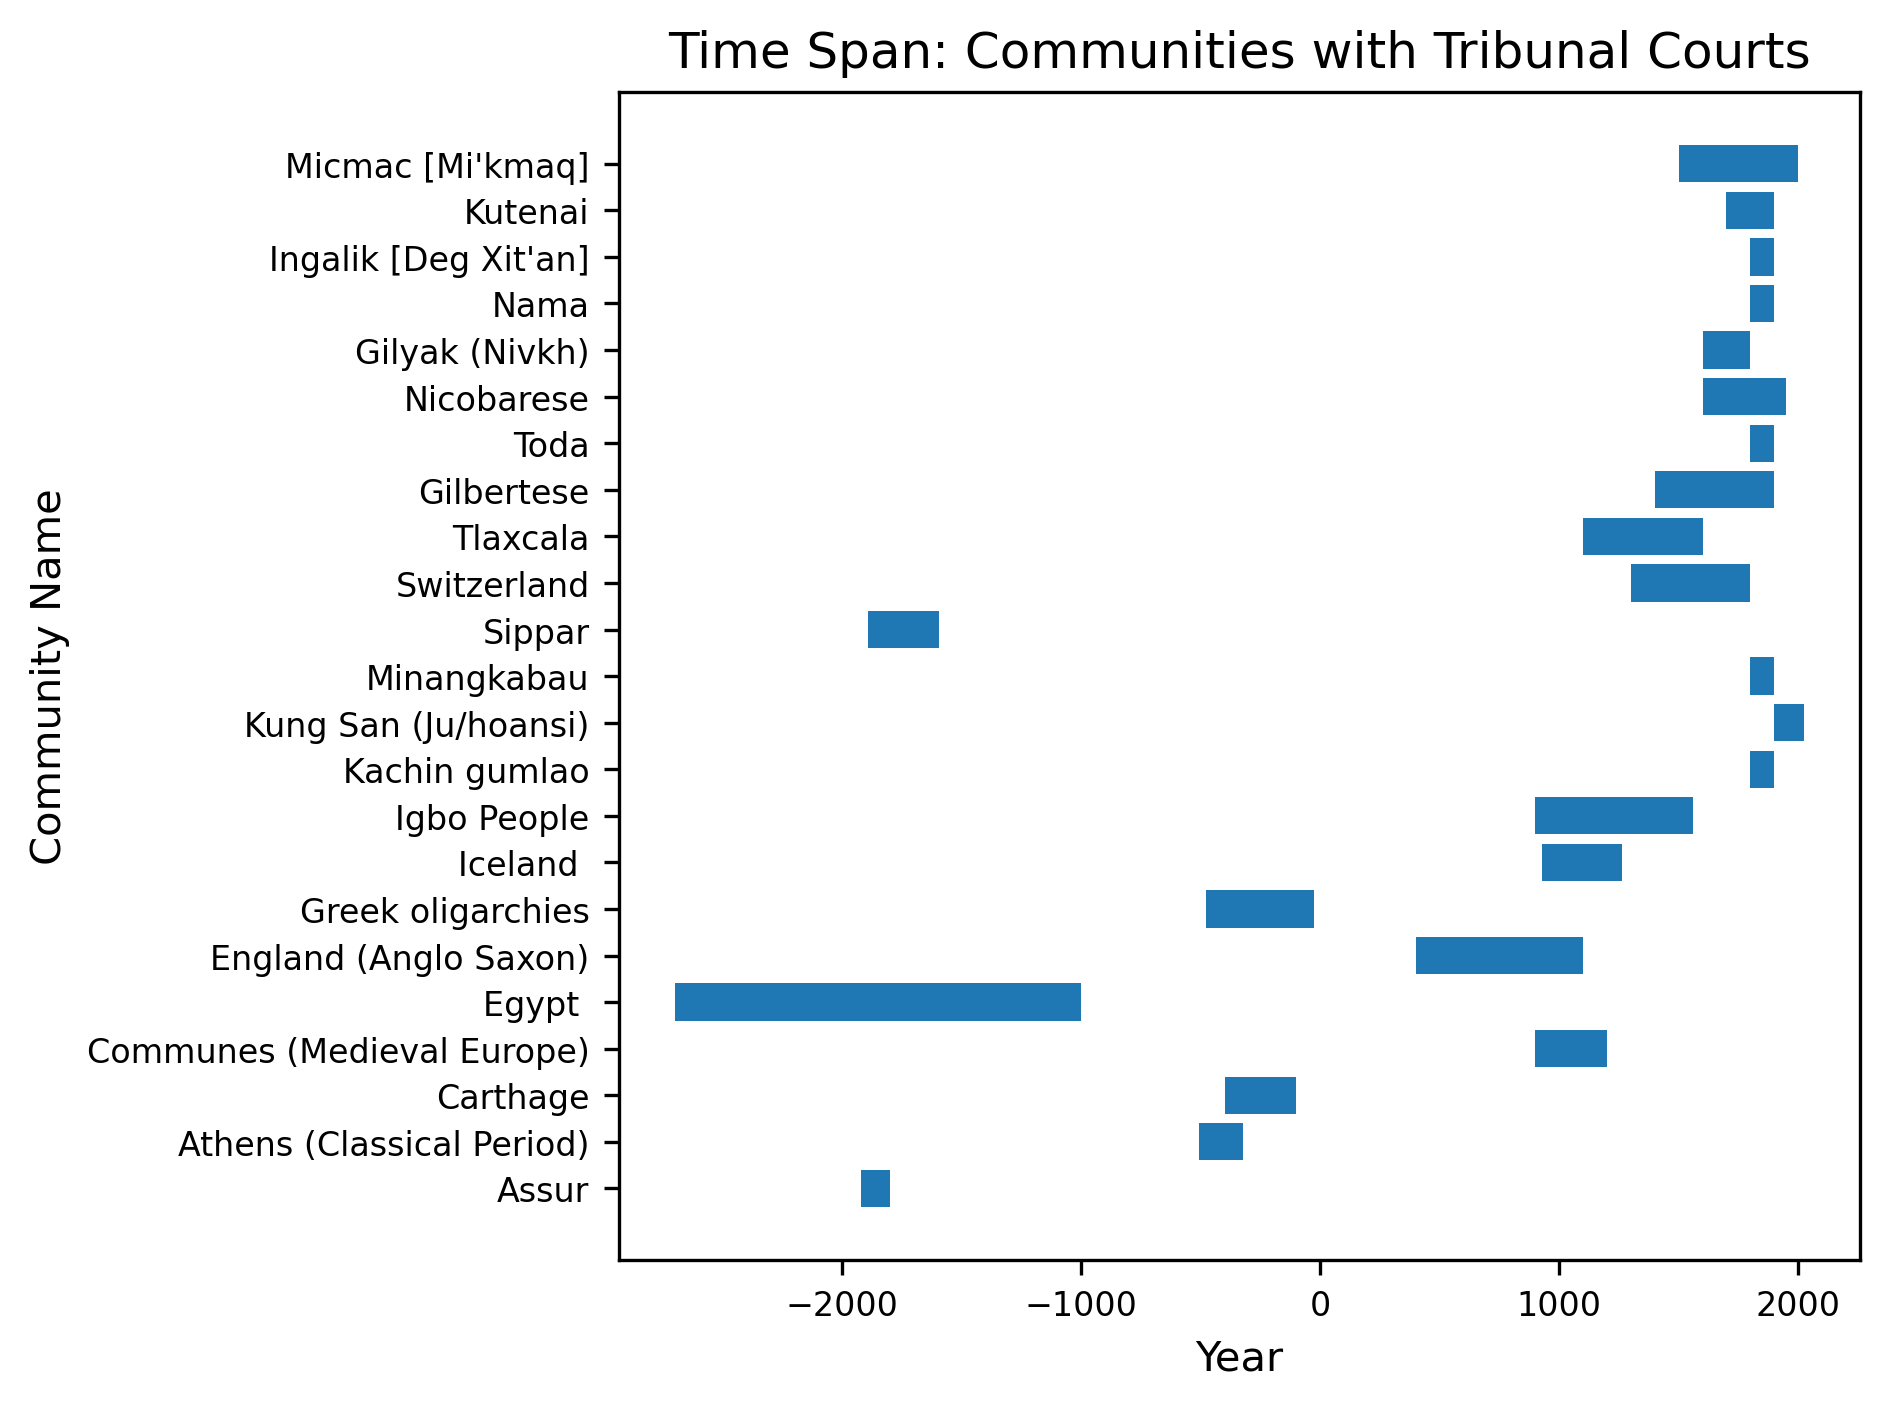

In [61]:
# create figure and plot
fig, ax = plt.subplots()
labels = []
for i, (
    start, 
    duration, 
    label, 
    has_courts,
) in enumerate(courts_dates_tuples):
    # bar_color = 'blue'
    
    labels.append(label)
    ax.broken_barh(
        [(start, duration)], 
        (i-0.4,0.8),
        # color=bar_color
    )
    
# set yticks at the middle of the bars
ax.set_yticks(range(len(courts_dates_tuples)))
ax.set_yticklabels(labels)
ax.tick_params(axis='both', which='major', labelsize=8)

ax.set_xlabel('Year')
ax.set_ylabel('Community Name')

plt.title('Time Span: Communities with Tribunal Courts')
# plt.figure(figsize=(80, 80))

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-courts/timeline_courts.png')
plt.show()